# Initial Visualizations Notebook

This notebook consolidates model comparisons across three tasks:

1. All-class SHD (20-way classification)
2. 2-class parity task
3. 4-class parity-language task

## Design compromises in the local-level networks (and direct repo comparison)

To make apples-to-apples comparisons with the repository baselines while keeping runs tractable, we used three local-level network variants that intentionally trade off flexibility vs stability:

1. **Local-Hom (shared time constants)**
   - One shared recurrent time-constant profile across hidden neurons.
   - Compromise: strongest regularization and best training stability, but least neuron-level temporal diversity.

2. **FittedHet-LogNorm (fixed heterogeneous \(\tau\) from fitted distributions)**
   - Per-neuron heterogeneity is injected by sampling from fitted distributions (Gamma synaptic, LogNormal membrane).
   - Compromise: captures realistic heterogeneity without learning every \(\tau\), but cannot adapt \(\tau\) per task after initialization.

3. **FittedHet-LogUniform (fixed heterogeneous \(\tau\), wider membrane support)**
   - Same principle as above, with LogUniform membrane sampling for broader coverage.
   - Compromise: explores broader timing regimes, but can be noisier in optimization and interpretation.

### Direct comparison to repository-style learned-heterogeneity networks

Relative to the repo-style **learned heterogeneity** network (per-neuron \(\tau\) learned end-to-end), these local designs intentionally reduce optimization complexity and improve reproducibility:

- **Pros of local design choices:**
  - Faster sweeps and ablations across tasks.
  - More controlled comparisons (architecture/dataset changes are easier to isolate).
  - Lower risk of unstable \(\tau\)-learning dynamics dominating results.

- **Cons vs repo learned-heterogeneity:**
  - Less expressive temporal adaptation because fitted \(\tau\) values are fixed.
  - Possible underfitting of task-specific temporal structure.

In short: we trade some expressivity for cleaner experimental control and repeatable cross-task comparisons.

---

The sections below provide:

1. Summary tables for all-class, 2-class, and 4-class networks.
2. Comprehensive visualization suite across all three network families.
3. PCA variance decay analysis.
4. Z-score/null-scoring visual summaries.
5. Membrane-vs-spike (mem vs spk) M-information change analysis.
6. Final scatter: task performance vs one average M-information value per network (all 9 networks).

In [ ]:
from __future__ import annotations

import io
import json
import sys
from contextlib import contextmanager, redirect_stdout
from pathlib import Path

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import rankdata

PROJECT_ROOT = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)")
PROJECT_FILES = PROJECT_ROOT / "Project Files"
CHECKPOINT_DIR = PROJECT_FILES / "Checkpoints"
PARITY_CKPT_DIR = CHECKPOINT_DIR / "Parity"
NULL_CACHE_DIR = PROJECT_FILES / "Null Caches"

WIMFO_ROOT = PROJECT_ROOT / "wimfo"
PAPER_ROOT = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from data_gen import open_file
from wimfo.W_M_Info import W_M_calculator
from wimfo.utils.utils_gauss import get_cov

RSNN = importlib.import_module("model").RSNN
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SHD_TEST = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"

SUBSET_SIZES = [2, 4, 8, 16, 32]

NETWORK_CATALOG = [
    {
        "network_id": "all_local_hom",
        "short": "ALL-LH",
        "task": "all-class",
        "arch": "Local-Hom",
        "display": "All-class | Local-Hom",
        "checkpoint": CHECKPOINT_DIR / "local_hom_checkpoint.pt",
        "mem_path": PROJECT_FILES / "sample_subset_local_hom_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "initial_viz_all_local_hom_spk_observed_wm_sweep.json",
    },
    {
        "network_id": "all_fittedhet_ln",
        "short": "ALL-LN",
        "task": "all-class",
        "arch": "FittedHet-LogNorm",
        "display": "All-class | FittedHet-LogNorm",
        "checkpoint": CHECKPOINT_DIR / "fittedhet_lognorm_mem_gamma_syn_checkpoint.pt",
        "mem_path": PROJECT_FILES / "sample_subset_fittedhet_lognormmem_gammasyn_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "initial_viz_all_fittedhet_ln_spk_observed_wm_sweep.json",
    },
    {
        "network_id": "all_fittedhet_lu",
        "short": "ALL-LU",
        "task": "all-class",
        "arch": "FittedHet-LogUniform",
        "display": "All-class | FittedHet-LogUniform",
        "checkpoint": CHECKPOINT_DIR / "fittedhet_loguniform_mem_gamma_syn_checkpoint.pt",
        "mem_path": PROJECT_FILES / "sample_subset_fittedhet_loguniformmem_gammasyn_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "initial_viz_all_fittedhet_lu_spk_observed_wm_sweep.json",
    },
    {
        "network_id": "2class_local_hom",
        "short": "2C-LH",
        "task": "2-class",
        "arch": "Local-Hom",
        "display": "2-class | Local-Hom",
        "checkpoint": PARITY_CKPT_DIR / "2class_local_hom.pt",
        "mem_path": PROJECT_FILES / "parity_2class_local_hom_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_2class_local_hom_spk_zero_m_zscore_sweep.json",
    },
    {
        "network_id": "2class_fittedhet_ln",
        "short": "2C-LN",
        "task": "2-class",
        "arch": "FittedHet-LogNorm",
        "display": "2-class | FittedHet-LogNorm",
        "checkpoint": PARITY_CKPT_DIR / "2class_fittedhet_lognorm.pt",
        "mem_path": PROJECT_FILES / "parity_2class_fittedhet_ln_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_2class_fittedhet_ln_spk_zero_m_zscore_sweep.json",
    },
    {
        "network_id": "2class_fittedhet_lu",
        "short": "2C-LU",
        "task": "2-class",
        "arch": "FittedHet-LogUniform",
        "display": "2-class | FittedHet-LogUniform",
        "checkpoint": PARITY_CKPT_DIR / "2class_fittedhet_loguniform.pt",
        "mem_path": PROJECT_FILES / "parity_2class_fittedhet_lu_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_2class_fittedhet_lu_spk_zero_m_zscore_sweep.json",
    },
    {
        "network_id": "4class_local_hom",
        "short": "4C-LH",
        "task": "4-class",
        "arch": "Local-Hom",
        "display": "4-class | Local-Hom",
        "checkpoint": PARITY_CKPT_DIR / "4class_local_hom.pt",
        "mem_path": PROJECT_FILES / "parity_4class_local_hom_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_4class_local_hom_spk_zero_m_zscore_sweep.json",
    },
    {
        "network_id": "4class_fittedhet_ln",
        "short": "4C-LN",
        "task": "4-class",
        "arch": "FittedHet-LogNorm",
        "display": "4-class | FittedHet-LogNorm",
        "checkpoint": PARITY_CKPT_DIR / "4class_fittedhet_lognorm.pt",
        "mem_path": PROJECT_FILES / "parity_4class_fittedhet_ln_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_4class_fittedhet_ln_spk_zero_m_zscore_sweep.json",
    },
    {
        "network_id": "4class_fittedhet_lu",
        "short": "4C-LU",
        "task": "4-class",
        "arch": "FittedHet-LogUniform",
        "display": "4-class | FittedHet-LogUniform",
        "checkpoint": PARITY_CKPT_DIR / "4class_fittedhet_loguniform.pt",
        "mem_path": PROJECT_FILES / "parity_4class_fittedhet_lu_mem_zero_m_zscore_sweep.json",
        "spk_path": PROJECT_FILES / "parity_4class_fittedhet_lu_spk_zero_m_zscore_sweep.json",
    },
]

REPO_REFERENCE = {
    "network_id": "repo_local_het_learned",
    "short": "ALL-RepoHet",
    "task": "all-class",
    "arch": "Repo-Learned-Het",
    "display": "All-class | Repo Local-Het-Learned",
    "checkpoint": CHECKPOINT_DIR / "network_A_checkpoint.pt",
    "mem_path": PROJECT_FILES / "sample_subset_local_het_learned_zero_m_zscore_sweep.json",
}

ARCH_ORDER = ["Local-Hom", "FittedHet-LogNorm", "FittedHet-LogUniform"]
TASK_ORDER = ["all-class", "2-class", "4-class"]
ARCH_COLORS = {
    "Local-Hom": "#4c78a8",
    "FittedHet-LogNorm": "#54a24b",
    "FittedHet-LogUniform": "#e45756",
}
TASK_MARKERS = {"all-class": "o", "2-class": "s", "4-class": "^"}

print(f"Device: {DEVICE}")
print(f"SHD test exists: {SHD_TEST.exists()}")
print(f"Project files: {PROJECT_FILES}")
print(f"Networks configured: {len(NETWORK_CATALOG)} (+1 repo reference)")

Device: cuda
SHD test exists: True
Project files: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files
Networks configured: 9 (+1 repo reference)


In [2]:
def load_json_payload(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)
    return payload if isinstance(payload, dict) else {}


def load_sweep_results(path: Path) -> list[dict]:
    payload = load_json_payload(path)
    if isinstance(payload.get("results"), list):
        return payload["results"]
    if isinstance(payload.get("data"), list):
        return payload["data"]
    if isinstance(payload, list):
        return payload
    return []


def save_json_payload(payload: dict, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(path)


def row_value(row: dict, keys: list[str], default=np.nan):
    for key in keys:
        if key in row:
            try:
                return float(row[key])
            except Exception:
                return default
    return default


def checkpoint_final_accuracy(ckpt_path: Path) -> float:
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        return float("nan")
    payload = torch.load(ckpt_path, map_location="cpu")
    if isinstance(payload.get("history"), dict) and payload["history"].get("test_acc"):
        return float(payload["history"]["test_acc"][-1])
    if "final_test_acc" in payload:
        return float(payload["final_test_acc"])
    return float("nan")


def flatten_sweep_rows(entry: dict, tensor: str, rows: list[dict], final_test_acc: float) -> list[dict]:
    flat = []
    for row in rows:
        subset_size = int(row.get("subset_size", -1))
        if subset_size < 0:
            continue
        flat.append(
            {
                "network_id": entry["network_id"],
                "short": entry["short"],
                "display": entry["display"],
                "task": entry["task"],
                "arch": entry["arch"],
                "tensor": tensor,
                "subset_size": subset_size,
                "final_test_acc": float(final_test_acc),
                "observed_M_bits": row_value(row, ["observed_M_bits", "M_bits"]),
                "observed_W_bits": row_value(row, ["observed_W_bits", "W_bits"]),
                "M_zscore": row_value(row, ["M_zscore"]),
                "W_zscore": row_value(row, ["W_zscore"]),
                "M_p_upper": row_value(row, ["M_p_upper"]),
                "W_p_upper": row_value(row, ["W_p_upper"]),
                "samples": row_value(row, ["samples"]),
                "status": str(row.get("status", "unknown")),
            }
        )
    return flat


def load_artifact_dataframe(network_catalog: list[dict]) -> pd.DataFrame:
    records = []
    for entry in network_catalog:
        acc = checkpoint_final_accuracy(entry["checkpoint"])

        mem_rows = load_sweep_results(entry["mem_path"])
        records.extend(flatten_sweep_rows(entry, "mem", mem_rows, acc))

        spk_rows = load_sweep_results(entry["spk_path"]) if Path(entry["spk_path"]).exists() else []
        if spk_rows:
            records.extend(flatten_sweep_rows(entry, "spk", spk_rows, acc))

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values(["task", "network_id", "tensor", "subset_size"]).reset_index(drop=True)
    return df


def build_task_summary(task_df: pd.DataFrame, subset_focus: int = 32) -> pd.DataFrame:
    rows = []
    for network_id, group in task_df.groupby("network_id"):
        row = {
            "network_id": network_id,
            "short": group["short"].iloc[0],
            "arch": group["arch"].iloc[0],
            "task": group["task"].iloc[0],
            "final_test_acc": float(group["final_test_acc"].iloc[0]),
            "avg_M": float(group["observed_M_bits"].mean()),
            "avg_W": float(group["observed_W_bits"].mean()),
        }
        for k in SUBSET_SIZES:
            subset_vals = group[group["subset_size"] == k]
            row[f"M@{k}"] = float(subset_vals["observed_M_bits"].iloc[0]) if not subset_vals.empty else float("nan")
            row[f"W@{k}"] = float(subset_vals["observed_W_bits"].iloc[0]) if not subset_vals.empty else float("nan")
        focus_vals = group[group["subset_size"] == int(subset_focus)]
        row["Mz@focus"] = float(focus_vals["M_zscore"].iloc[0]) if not focus_vals.empty else float("nan")
        row["Mp@focus"] = float(focus_vals["M_p_upper"].iloc[0]) if not focus_vals.empty else float("nan")
        rows.append(row)
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["task", "arch", "network_id"]).reset_index(drop=True)
    return out


artifact_df = load_artifact_dataframe(NETWORK_CATALOG)
print(f"Loaded artifact rows: {len(artifact_df)}")
print(f"Tensors available: {sorted(artifact_df['tensor'].unique()) if not artifact_df.empty else []}")

mem_df = artifact_df[artifact_df["tensor"] == "mem"].copy()
print(f"Mem rows available: {len(mem_df)}")

Loaded artifact rows: 75
Tensors available: ['mem', 'spk']
Mem rows available: 45


In [3]:
if mem_df.empty:
    raise RuntimeError("No mem-based sweep data loaded. Verify artifact paths.")

all_class_table = build_task_summary(mem_df[mem_df["task"] == "all-class"], subset_focus=32)
two_class_table = build_task_summary(mem_df[mem_df["task"] == "2-class"], subset_focus=32)
four_class_table = build_task_summary(mem_df[mem_df["task"] == "4-class"], subset_focus=32)

print("All-class summary (Local-Hom vs two fitted heterogeneous variants)")
print("-" * 100)
print(all_class_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n2-class summary (all 2-class networks)")
print("-" * 100)
print(two_class_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n4-class summary (all 4-class networks)")
print("-" * 100)
print(four_class_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nSubset-wise observed M tables by task")
for task_name in TASK_ORDER:
    pivot = (
        mem_df[mem_df["task"] == task_name]
        .pivot(index="subset_size", columns="short", values="observed_M_bits")
        .reindex(index=SUBSET_SIZES)
        .sort_index(axis=1)
    )
    print(f"\nTask={task_name}")
    print(pivot.to_string(float_format=lambda v: f"{v:.4f}"))

repo_rows = load_sweep_results(REPO_REFERENCE["mem_path"])
repo_acc = checkpoint_final_accuracy(REPO_REFERENCE["checkpoint"])
repo_focus = next((r for r in repo_rows if int(r.get("subset_size", -1)) == 32), {})
repo_avg_m = np.nanmean([row_value(r, ["observed_M_bits", "M_bits"]) for r in repo_rows]) if repo_rows else float("nan")

repo_compare = all_class_table[["network_id", "short", "arch", "final_test_acc", "avg_M", "M@32", "Mz@focus"]].copy()
repo_compare = pd.concat(
    [
        repo_compare,
        pd.DataFrame(
            [
                {
                    "network_id": REPO_REFERENCE["network_id"],
                    "short": REPO_REFERENCE["short"],
                    "arch": REPO_REFERENCE["arch"],
                    "final_test_acc": repo_acc,
                    "avg_M": float(repo_avg_m),
                    "M@32": row_value(repo_focus, ["observed_M_bits", "M_bits"]),
                    "Mz@focus": row_value(repo_focus, ["M_zscore"]),
                }
            ]
        ),
    ],
    ignore_index=True,
)

print("\nDirect all-class comparison against repo learned-heterogeneity reference")
print("-" * 100)
print(repo_compare.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

All-class summary (Local-Hom vs two fitted heterogeneous variants)
----------------------------------------------------------------------------------------------------
      network_id  short                 arch      task  final_test_acc  avg_M   avg_W     M@2    W@2    M@4    W@4    M@8     W@8   M@16    W@16   M@32    W@32   Mz@focus  Mp@focus
all_fittedhet_ln ALL-LN    FittedHet-LogNorm all-class          0.6904 0.3663  9.7509  0.0037 2.0451 0.0070 4.5814 0.0774  8.8412 0.2225 16.6724 1.5209 16.6140 17677.9227    0.0050
all_fittedhet_lu ALL-LU FittedHet-LogUniform all-class          0.6007 0.3237 11.2668 -0.0054 4.8699 0.0031 7.3525 0.0560 11.0241 0.2207 17.3309 1.3442 15.7564 15621.5939    0.0050
   all_local_hom ALL-LH            Local-Hom all-class          0.6524 0.5616 11.3017 -0.0027 5.1484 0.0030 8.1149 0.0825 12.0805 0.3767 17.1805 2.3486 13.9844 27307.5839    0.0050

2-class summary (all 2-class networks)
--------------------------------------------------------------------

## Hyperparameter Comparison: Repo vs Local All-Class Architectures

The table below directly compares checkpoint hyperparameters for:

1. Repo learned-heterogeneity reference network
2. Local-Hom (all-class)
3. FittedHet-LogNorm (all-class)
4. FittedHet-LogUniform (all-class)

A transposed table is included so each hyperparameter can be compared row-by-row across networks.

In [9]:
def _fmt_val(v):
    if isinstance(v, float):
        if np.isfinite(v):
            return f"{v:.6g}"
        return "nan"
    if isinstance(v, (list, tuple)):
        return str(list(v))
    return str(v)


def _safe_param(prms: dict, key: str, default=np.nan):
    val = prms.get(key, default)
    if isinstance(val, torch.device):
        return str(val)
    if isinstance(val, torch.dtype):
        return str(val)
    if isinstance(val, np.ndarray):
        return val.tolist()
    return val


all_class_locals = [entry for entry in NETWORK_CATALOG if entry["task"] == "all-class"]
compare_entries = [REPO_REFERENCE, *all_class_locals]

hp_rows = []
for entry in compare_entries:
    ckpt = torch.load(entry["checkpoint"], map_location="cpu")
    prms = dict(ckpt.get("prms", {}))

    class_list = _safe_param(prms, "class_list", [])
    class_count = len(class_list) if isinstance(class_list, list) else np.nan

    row = {
        "network_id": entry["network_id"],
        "short": entry.get("short", entry["network_id"]),
        "source": "repo" if entry["network_id"] == REPO_REFERENCE["network_id"] else "local",
        "arch": entry.get("arch", "unknown"),
        "nb_inputs": _safe_param(prms, "nb_inputs"),
        "nb_recurrent": _safe_param(prms, "nb_recurrent"),
        "nb_outputs": _safe_param(prms, "nb_outputs"),
        "batch_size": _safe_param(prms, "batch_size"),
        "time_step_ms": float(_safe_param(prms, "time_step", np.nan)) * 1e3 if np.isfinite(float(_safe_param(prms, "time_step", np.nan))) else np.nan,
        "nb_steps": _safe_param(prms, "nb_steps"),
        "nb_epochs": _safe_param(prms, "nb_epochs"),
        "lr": _safe_param(prms, "lr"),
        "lr_ab": _safe_param(prms, "lr_ab"),
        "betas": _safe_param(prms, "betas"),
        "weight_decay": _safe_param(prms, "weight_decay"),
        "clip": _safe_param(prms, "clip"),
        "het_ab": _safe_param(prms, "het_ab"),
        "train_ab": _safe_param(prms, "train_ab"),
        "train_hom_ab": _safe_param(prms, "train_hom_ab"),
        "class_count": class_count,
        "dist": _safe_param(prms, "dist"),
        "dist_prms": _safe_param(prms, "dist_prms"),
        "time_scale": _safe_param(prms, "time_scale"),
        "model": _safe_param(prms, "model"),
    }
    hp_rows.append(row)

hp_df = pd.DataFrame(hp_rows)
col_order = [
    "network_id",
    "short",
    "source",
    "arch",
    "nb_inputs",
    "nb_recurrent",
    "nb_outputs",
    "batch_size",
    "time_step_ms",
    "nb_steps",
    "nb_epochs",
    "lr",
    "lr_ab",
    "betas",
    "weight_decay",
    "clip",
    "het_ab",
    "train_ab",
    "train_hom_ab",
    "class_count",
    "dist",
    "dist_prms",
    "time_scale",
    "model",
]
hp_df = hp_df[col_order]

print("Repo vs local all-class hyperparameter table")
print("-" * 120)
print(hp_df.to_string(index=False, formatters={c: _fmt_val for c in hp_df.columns}))

param_cols = [c for c in col_order if c not in ["network_id", "short", "source", "arch"]]
hp_transposed = hp_df.set_index("short")[param_cols].T
print("\nDirect row-wise comparison (hyperparameter x network)")
print("-" * 120)
print(hp_transposed.to_string(formatters={c: _fmt_val for c in hp_transposed.columns}))

if "ALL-RepoHet" in hp_df["short"].values:
    repo_row = hp_df[hp_df["short"] == "ALL-RepoHet"].iloc[0]
    compare_rows = []
    for _, local_row in hp_df[hp_df["source"] == "local"].iterrows():
        match_count = 0
        total_count = 0
        for p in param_cols:
            rv = repo_row[p]
            lv = local_row[p]
            if isinstance(rv, float) and np.isnan(rv) and isinstance(lv, float) and np.isnan(lv):
                continue
            total_count += 1
            if str(rv) == str(lv):
                match_count += 1
        compare_rows.append(
            {
                "local_network": local_row["short"],
                "matches_repo": int(match_count),
                "total_compared": int(total_count),
                "match_fraction": float(match_count / total_count) if total_count > 0 else np.nan,
            }
        )
    hp_match_df = pd.DataFrame(compare_rows)
    print("\nLocal-vs-repo hyperparameter overlap summary")
    print("-" * 120)
    print(hp_match_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Repo vs local all-class hyperparameter table
------------------------------------------------------------------------------------------------------------------------
            network_id       short source                 arch nb_inputs nb_recurrent nb_outputs batch_size time_step_ms nb_steps nb_epochs    lr lr_ab        betas weight_decay clip het_ab train_ab train_hom_ab class_count  dist dist_prms time_scale model
repo_local_het_learned ALL-RepoHet   repo     Repo-Learned-Het       700           32         20        256            1     1000        25 0.004 0.004 [0.9, 0.999]            0    1      1        1            0          20 gamma         3 [0.5, 1.0]  RSNN
         all_local_hom      ALL-LH  local            Local-Hom       700           32         20        256            1     1000        25 0.004 0.004 [0.9, 0.999]            0    1      0        0            1          20 gamma         3 [0.5, 1.0]  RSNN
      all_fittedhet_ln      ALL-LN  local    FittedHet-LogNorm 

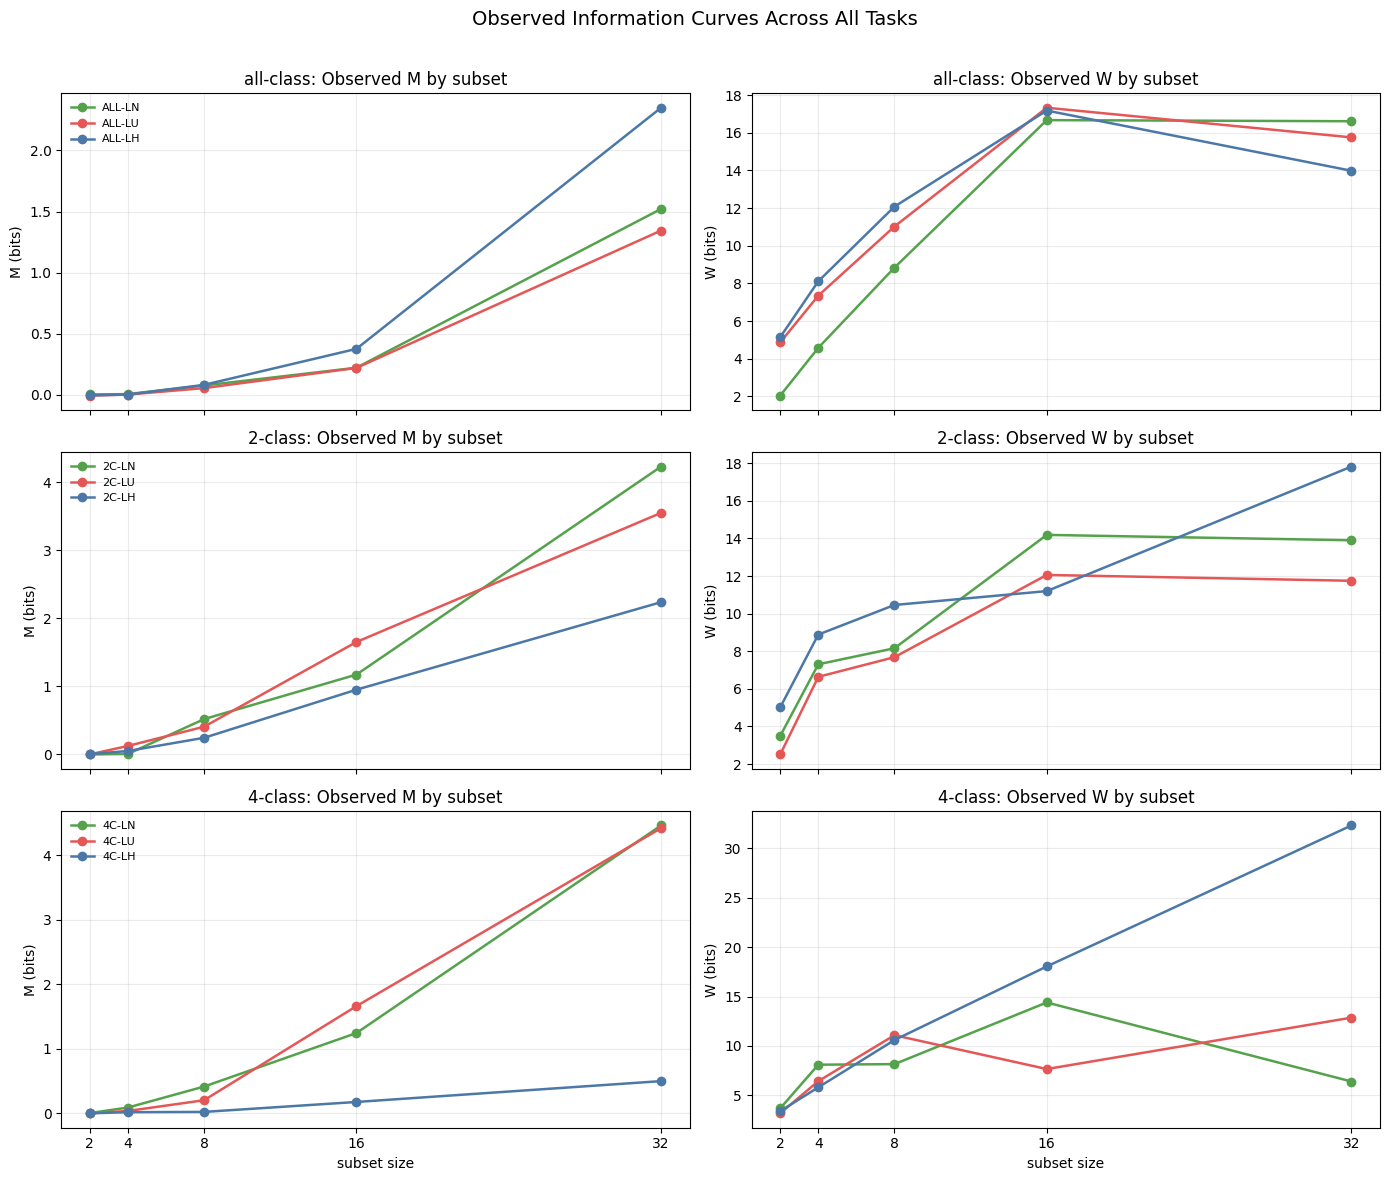

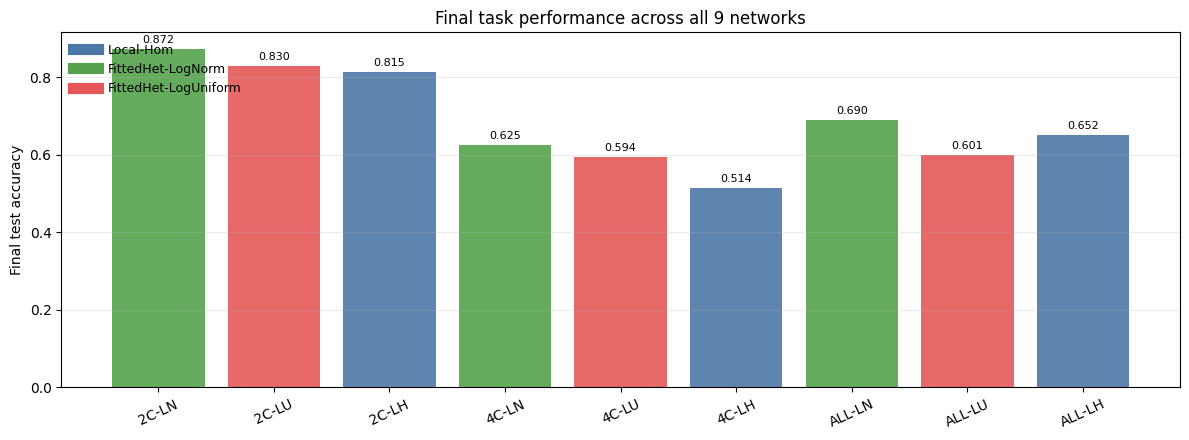

In [8]:
def dedup_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    return list(unique.values()), list(unique.keys())


fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for row_idx, task_name in enumerate(TASK_ORDER):
    task_df = mem_df[mem_df["task"] == task_name].copy()
    for network_id in task_df["network_id"].unique():
        group = task_df[task_df["network_id"] == network_id].sort_values("subset_size")
        arch = group["arch"].iloc[0]
        color = ARCH_COLORS.get(arch, "#666666")
        label = group["short"].iloc[0]

        axes[row_idx, 0].plot(
            group["subset_size"],
            group["observed_M_bits"],
            marker="o",
            linewidth=1.8,
            color=color,
            label=label,
        )
        axes[row_idx, 1].plot(
            group["subset_size"],
            group["observed_W_bits"],
            marker="o",
            linewidth=1.8,
            color=color,
            label=label,
        )

    axes[row_idx, 0].set_title(f"{task_name}: Observed M by subset")
    axes[row_idx, 0].set_ylabel("M (bits)")
    axes[row_idx, 0].grid(alpha=0.25)

    axes[row_idx, 1].set_title(f"{task_name}: Observed W by subset")
    axes[row_idx, 1].set_ylabel("W (bits)")
    axes[row_idx, 1].grid(alpha=0.25)

    h, l = dedup_legend(axes[row_idx, 0])
    axes[row_idx, 0].legend(h, l, fontsize=8, frameon=False, loc="best")

for ax in axes[-1, :]:
    ax.set_xlabel("subset size")
for ax in axes.flat:
    ax.set_xticks(SUBSET_SIZES)

plt.suptitle("Observed Information Curves Across All Tasks", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

acc_plot_df = (
    mem_df[["network_id", "short", "task", "arch", "final_test_acc"]]
    .drop_duplicates()
    .sort_values(["task", "arch", "short"])
)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(acc_plot_df))
bar_colors = [ARCH_COLORS.get(a, "#666666") for a in acc_plot_df["arch"]]
ax.bar(x, acc_plot_df["final_test_acc"], color=bar_colors, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(acc_plot_df["short"], rotation=25)
ax.set_ylabel("Final test accuracy")
ax.set_title("Final task performance across all 9 networks")
ax.grid(axis="y", alpha=0.25)
for idx, value in enumerate(acc_plot_df["final_test_acc"]):
    ax.text(idx, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

legend_handles = []
for arch in ARCH_ORDER:
    legend_handles.append(plt.Line2D([0], [0], color=ARCH_COLORS[arch], lw=8, label=arch))
ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

In [4]:
class SHDCache:
    def __init__(self, path: Path):
        units, times, labels = open_file(str(path))
        self.units = list(units[:])
        self.times = list(times[:])
        self.labels = np.array(labels[:])
        units._v_file.close()


def _is_cache(obj) -> bool:
    return hasattr(obj, "units") and hasattr(obj, "times") and hasattr(obj, "labels")


@contextmanager
def shd_open_cached(cache: SHDCache):
    yield cache.units, cache.times, cache.labels


def fast_sparse_data_generator(units, times, labels, prms, shuffle=True, epoch=0, drop_last=True):
    batch_size = int(prms.get("batch_size", 256))
    nb_steps = int(prms.get("nb_steps", 1000))
    nb_units = int(prms.get("nb_inputs", 700))
    inv_dt = 1.0 / float(prms.get("time_step", 1e-3))
    class_list = prms.get("class_list", list(range(20)))
    task_label_map = prms.get("task_label_map", None)

    label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples = len(sample_index)
    n_batches = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)

    rng = np.random.default_rng(int(prms.get("seed", 1000)) + int(epoch))
    if shuffle:
        rng.shuffle(sample_index)

    for counter in range(n_batches):
        batch_index = sample_index[batch_size * counter : min(num_samples, batch_size * (counter + 1))]
        actual_bs = len(batch_index)
        if actual_bs == 0:
            continue

        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum() > 0:
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            idx_tensor = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            val_tensor = torch.ones(all_ts.size, dtype=torch.float32)
            x_batch = torch.sparse_coo_tensor(idx_tensor, val_tensor, torch.Size([actual_bs, nb_steps, nb_units])).to_dense()
        else:
            x_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        x_batch.clamp_(max=1.0)

        if task_label_map is not None:
            y_batch = torch.tensor([task_label_map[int(a)] for a in label_arr[batch_index]], dtype=torch.long)
        else:
            y_batch = torch.tensor([class_list.index(int(a)) for a in label_arr[batch_index]], dtype=torch.long)

        yield x_batch, y_batch


def shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False):
    yield from fast_sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)


def gaussian_copula_normalize(data: np.ndarray) -> np.ndarray:
    transformed = np.zeros_like(data, dtype=np.float64)
    for idx, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks = rankdata(row, method="average")
        uniform = np.clip((ranks - 0.5) / len(row), 1e-6, 1.0 - 1e-6)
        transformed[idx] = np.sqrt(2.0) * torch.erfinv(torch.tensor(2.0 * uniform - 1.0)).numpy()
    return transformed


def inject_small_jitter(data: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    row_std = np.nanstd(data, axis=1)
    deg_idx = np.flatnonzero(row_std <= 1e-12)
    if deg_idx.size == 0:
        return data
    base = np.linspace(-1.0, 1.0, data.shape[1], dtype=np.float64)
    for offset, ridx in enumerate(deg_idx, start=1):
        data[ridx] = (eps * offset) * base
    return data


def compute_wm_from_hidden_matrix(hidden_data: np.ndarray, lag: int = 1, ridge: float = 1e-2) -> dict:
    g = gaussian_copula_normalize(hidden_data)
    g = np.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
    g = inject_small_jitter(g)

    try:
        with io.StringIO() as _buf, redirect_stdout(_buf):
            w_bits, m_bits = W_M_calculator(g, t=int(lag), option="data", type="gaussian", unit="bits", verbose=False, optimiser="Adam", options={"atol": 1e-3, "rtol": 1e-3, "max_iter": 30000})
        if np.isfinite(w_bits) and np.isfinite(m_bits):
            return {"W_bits": float(w_bits), "M_bits": float(m_bits), "optimiser": "Adam(data)", "samples": int(g.shape[1])}
    except Exception:
        pass

    cov = np.asarray(get_cov(g, t=int(lag)), dtype=np.float64)
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if not np.isfinite(scale) or scale <= 0.0:
        scale = 1.0
    cov = cov + float(ridge) * scale * np.eye(cov.shape[0], dtype=np.float64)

    with io.StringIO() as _buf, redirect_stdout(_buf):
        w_bits, m_bits = W_M_calculator(cov, option="distr", type="gaussian", unit="bits", verbose=False, optimiser="Newton", options=None)
    if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
        raise RuntimeError("W/M calculation returned non-finite values")
    return {"W_bits": float(w_bits), "M_bits": float(m_bits), "optimiser": "Newton(distr)", "samples": int(g.shape[1])}


@torch.no_grad()
def collect_all_hidden_tensor(model, prms, data_source, tensor_key="mem", max_batches=2, downsample_stride=4):
    stride = max(int(downsample_stride), 1)
    nb_hidden = int(model.network[0].output_size)
    chunks = []

    if _is_cache(data_source):
        ctx = shd_open_cached
    else:
        raise RuntimeError("Expected SHDCache for data_source")

    with ctx(data_source) as (units, times, labels):
        for bidx, (x, _y) in enumerate(shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)):
            if bidx >= int(max_batches):
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            hidden = layer_recs[0][1] if tensor_key == "mem" else layer_recs[0][0]
            arr = hidden[:, ::stride, :].detach().cpu().numpy()
            arr = np.transpose(arr, (2, 0, 1)).reshape(nb_hidden, -1)
            chunks.append(arr)

    if not chunks:
        raise RuntimeError("No hidden chunks collected")
    return np.concatenate(chunks, axis=1)


def load_model_from_checkpoint(ckpt_path: Path):
    payload = torch.load(ckpt_path, map_location=DEVICE)
    prms = dict(payload.get("prms", {}))
    prms["device"] = DEVICE
    prms["cuda"] = bool(DEVICE.type == "cuda")
    prms["dtype"] = torch.float
    prms.setdefault("batch_size", 256)
    prms.setdefault("time_step", 1e-3)
    prms.setdefault("nb_steps", 1000)
    prms.setdefault("class_list", list(range(20)))

    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    return model, prms, payload


def compute_observed_sweep(hidden_matrix: np.ndarray, subset_sizes: list[int], lag: int = 1, ridge: float = 1e-2) -> list[dict]:
    rows = []
    hidden_size = int(hidden_matrix.shape[0])
    for subset_size in subset_sizes:
        idx = np.linspace(0, hidden_size - 1, min(int(subset_size), hidden_size), dtype=int)
        try:
            result = compute_wm_from_hidden_matrix(hidden_matrix[idx, :], lag=lag, ridge=ridge)
            row = {
                "subset_size": int(subset_size),
                "samples": int(result.get("samples", hidden_matrix.shape[1])),
                "observed_M_bits": float(result["M_bits"]),
                "observed_W_bits": float(result["W_bits"]),
                "status": "ok",
                "optimiser": result.get("optimiser", "unknown"),
            }
        except Exception as exc:
            row = {
                "subset_size": int(subset_size),
                "samples": int(hidden_matrix.shape[1]),
                "observed_M_bits": float("nan"),
                "observed_W_bits": float("nan"),
                "status": "error",
                "error": str(exc),
            }
        rows.append(row)
    return rows


if "SHD_TEST_CACHE" not in globals():
    SHD_TEST_CACHE = SHDCache(SHD_TEST)

all_class_entries = [entry for entry in NETWORK_CATALOG if entry["task"] == "all-class"]
missing_allclass_spk = [entry for entry in all_class_entries if not Path(entry["spk_path"]).exists()]

if missing_allclass_spk:
    print(f"Computing missing all-class spike sweeps for {len(missing_allclass_spk)} networks...")
    for entry in missing_allclass_spk:
        print(f"  -> {entry['network_id']}")
        model, prms, _payload = load_model_from_checkpoint(entry["checkpoint"])
        hidden_spk = collect_all_hidden_tensor(
            model,
            prms,
            SHD_TEST_CACHE,
            tensor_key="spk",
            max_batches=2,
            downsample_stride=4,
        )
        sweep_rows = compute_observed_sweep(hidden_spk, SUBSET_SIZES, lag=1, ridge=1e-2)
        save_json_payload(
            {
                "metadata": {
                    "label": entry["network_id"],
                    "task": entry["task"],
                    "tensor": "spk",
                    "subset_sizes": SUBSET_SIZES,
                    "generator": "initial_visualizations_notebook",
                },
                "results": sweep_rows,
            },
            entry["spk_path"],
        )
        print(f"     saved -> {entry['spk_path'].name}")
else:
    print("All-class spike sweep files already exist. Reusing cached artifacts.")

artifact_df = load_artifact_dataframe(NETWORK_CATALOG)
mem_df = artifact_df[artifact_df["tensor"] == "mem"].copy()
spk_df = artifact_df[artifact_df["tensor"] == "spk"].copy()

print(f"Refreshed artifact rows: {len(artifact_df)}")
print(f"Mem rows: {len(mem_df)} | Spk rows: {len(spk_df)}")

Computing missing all-class spike sweeps for 3 networks...
  -> all_local_hom
     saved -> initial_viz_all_local_hom_spk_observed_wm_sweep.json
  -> all_fittedhet_ln
     saved -> initial_viz_all_fittedhet_ln_spk_observed_wm_sweep.json
  -> all_fittedhet_lu
     saved -> initial_viz_all_fittedhet_lu_spk_observed_wm_sweep.json
Refreshed artifact rows: 90
Mem rows: 45 | Spk rows: 45


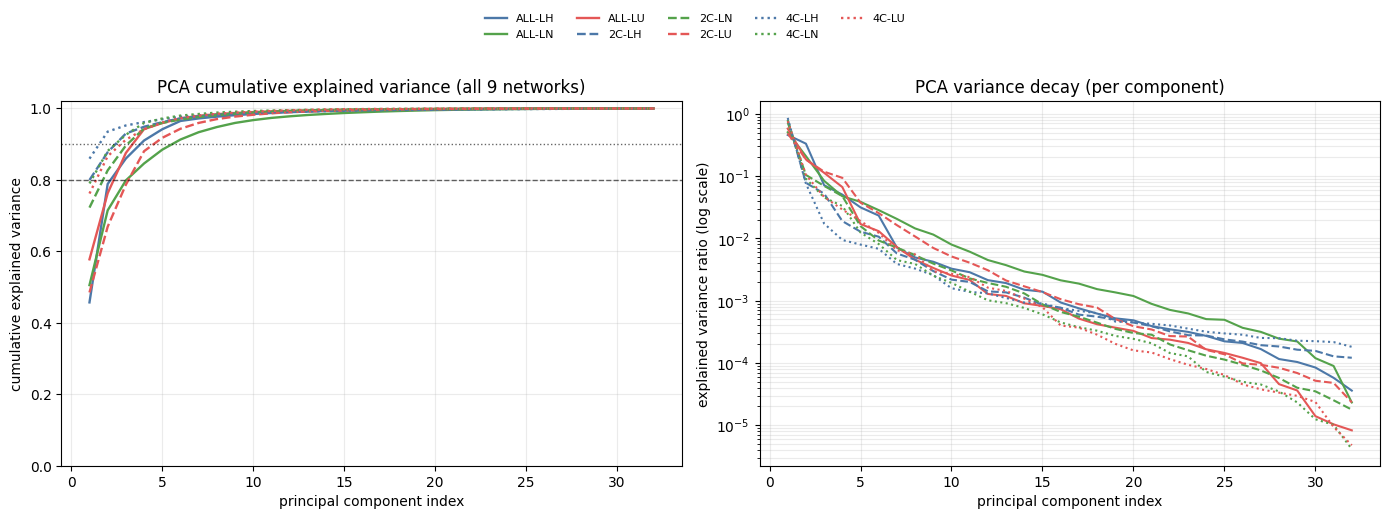

PCA variance-decay summary
----------------------------------------------------------------------------------------------------
         network_id  short      task                 arch  samples  components_total  cum_var_pc1  cum_var_pc2  cum_var_pc4  components_80pct  components_90pct  components_95pct
2class_fittedhet_ln  2C-LN   2-class    FittedHet-LogNorm   128000                32       0.7225       0.8268       0.9440                 2                 4                 5
2class_fittedhet_lu  2C-LU   2-class FittedHet-LogUniform   128000                32       0.4850       0.6691       0.8804                 4                 5                 7
   2class_local_hom  2C-LH   2-class            Local-Hom   128000                32       0.7997       0.8776       0.9489                 2                 3                 5
4class_fittedhet_ln  4C-LN   4-class    FittedHet-LogNorm   128000                32       0.7901       0.8810       0.9595                 2                 3 

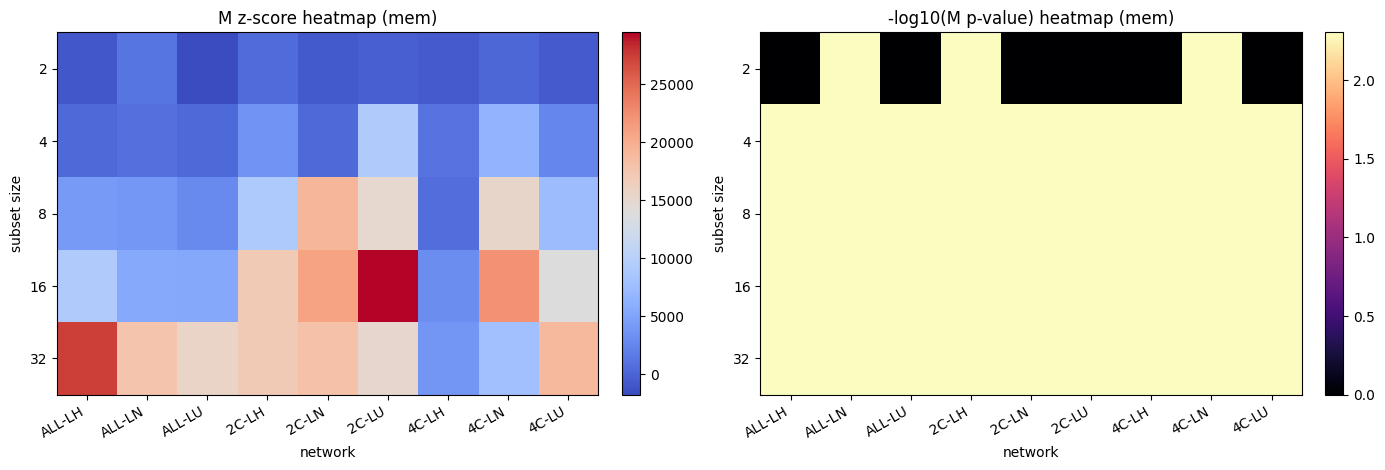

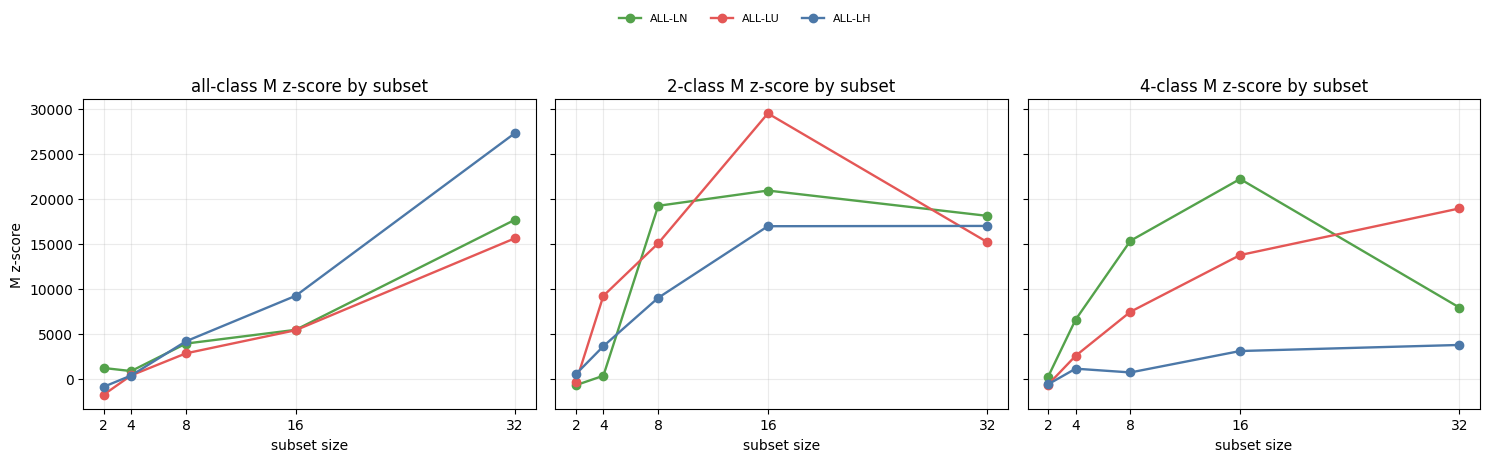

In [6]:
TASK_LINESTYLES = {"all-class": "-", "2-class": "--", "4-class": ":"}

if 'dedup_legend' not in globals():
    def dedup_legend(ax):
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        return list(unique.values()), list(unique.keys())

pca_profiles = {}
pca_rows = []

for entry in NETWORK_CATALOG:
    model, prms, _payload = load_model_from_checkpoint(entry["checkpoint"])
    hidden_mem = collect_all_hidden_tensor(
        model,
        prms,
        SHD_TEST_CACHE,
        tensor_key="mem",
        max_batches=2,
        downsample_stride=4,
    )

    subset_size = min(32, int(hidden_mem.shape[0]))
    idx = np.linspace(0, hidden_mem.shape[0] - 1, subset_size, dtype=int)
    x = hidden_mem[idx, :].T.astype(np.float64)
    x = x - x.mean(axis=0, keepdims=True)

    singular_values = np.linalg.svd(x, full_matrices=False, compute_uv=False)
    explained_variance = (singular_values ** 2) / max(x.shape[0] - 1, 1)
    total_variance = float(explained_variance.sum())
    evr = explained_variance / total_variance if total_variance > 0 else np.zeros_like(explained_variance)
    cumulative = np.cumsum(evr)

    pca_profiles[entry["network_id"]] = {
        "short": entry["short"],
        "task": entry["task"],
        "arch": entry["arch"],
        "evr": evr,
        "cumulative": cumulative,
        "samples": int(x.shape[0]),
    }

    def components_for_threshold(cum_vals, threshold):
        if cum_vals.size == 0:
            return 0
        idx_thr = int(np.searchsorted(cum_vals, threshold, side="left"))
        return min(idx_thr, cum_vals.size - 1) + 1

    pca_rows.append(
        {
            "network_id": entry["network_id"],
            "short": entry["short"],
            "task": entry["task"],
            "arch": entry["arch"],
            "samples": int(x.shape[0]),
            "components_total": int(evr.size),
            "cum_var_pc1": float(cumulative[0]) if cumulative.size >= 1 else float("nan"),
            "cum_var_pc2": float(cumulative[1]) if cumulative.size >= 2 else float("nan"),
            "cum_var_pc4": float(cumulative[3]) if cumulative.size >= 4 else float("nan"),
            "components_80pct": components_for_threshold(cumulative, 0.80),
            "components_90pct": components_for_threshold(cumulative, 0.90),
            "components_95pct": components_for_threshold(cumulative, 0.95),
        }
    )

pca_df = pd.DataFrame(pca_rows).sort_values(["task", "arch", "short"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for entry in NETWORK_CATALOG:
    profile = pca_profiles[entry["network_id"]]
    components = np.arange(1, profile["evr"].size + 1)
    color = ARCH_COLORS.get(entry["arch"], "#666666")
    linestyle = TASK_LINESTYLES.get(entry["task"], "-")
    label = entry["short"]

    axes[0].plot(components, profile["cumulative"], color=color, linestyle=linestyle, linewidth=1.7, label=label)
    axes[1].plot(components, profile["evr"], color=color, linestyle=linestyle, linewidth=1.5, label=label)

axes[0].axhline(0.80, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
axes[0].axhline(0.90, color="k", linestyle=":", linewidth=1.0, alpha=0.6)
axes[0].set_title("PCA cumulative explained variance (all 9 networks)")
axes[0].set_xlabel("principal component index")
axes[0].set_ylabel("cumulative explained variance")
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)

axes[1].set_yscale("log")
axes[1].set_title("PCA variance decay (per component)")
axes[1].set_xlabel("principal component index")
axes[1].set_ylabel("explained variance ratio (log scale)")
axes[1].grid(alpha=0.25, which="both")

handles, labels = dedup_legend(axes[0])
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("PCA variance-decay summary")
print("-" * 100)
print(pca_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

mem_z_df = mem_df[np.isfinite(mem_df["M_zscore"])].copy()
if mem_z_df.empty:
    print("No finite M_zscore values found in mem_df.")
else:
    subset_order = sorted(mem_z_df["subset_size"].unique())
    short_order = [entry["short"] for entry in NETWORK_CATALOG]

    pivot_z = mem_z_df.pivot(index="subset_size", columns="short", values="M_zscore").reindex(index=subset_order, columns=short_order)
    pivot_p = mem_z_df.pivot(index="subset_size", columns="short", values="M_p_upper").reindex(index=subset_order, columns=short_order)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    im0 = axes[0].imshow(pivot_z.to_numpy(dtype=float), aspect="auto", cmap="coolwarm")
    axes[0].set_title("M z-score heatmap (mem)")
    axes[0].set_xlabel("network")
    axes[0].set_ylabel("subset size")
    axes[0].set_xticks(np.arange(len(short_order)))
    axes[0].set_xticklabels(short_order, rotation=30, ha="right")
    axes[0].set_yticks(np.arange(len(subset_order)))
    axes[0].set_yticklabels(subset_order)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    neglogp = -np.log10(np.clip(pivot_p.to_numpy(dtype=float), 1e-12, 1.0))
    im1 = axes[1].imshow(neglogp, aspect="auto", cmap="magma")
    axes[1].set_title("-log10(M p-value) heatmap (mem)")
    axes[1].set_xlabel("network")
    axes[1].set_ylabel("subset size")
    axes[1].set_xticks(np.arange(len(short_order)))
    axes[1].set_xticklabels(short_order, rotation=30, ha="right")
    axes[1].set_yticks(np.arange(len(subset_order)))
    axes[1].set_yticklabels(subset_order)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, task_name in zip(axes, TASK_ORDER):
        task_rows = mem_z_df[mem_z_df["task"] == task_name]
        for network_id, group in task_rows.groupby("network_id"):
            arch = group["arch"].iloc[0]
            short = group["short"].iloc[0]
            ax.plot(group["subset_size"], group["M_zscore"], marker="o", linewidth=1.7, color=ARCH_COLORS.get(arch, "#666666"), label=short)
        ax.set_title(f"{task_name} M z-score by subset")
        ax.set_xlabel("subset size")
        ax.grid(alpha=0.25)
        ax.set_xticks(SUBSET_SIZES)
    axes[0].set_ylabel("M z-score")
    h, l = dedup_legend(axes[0])
    fig.legend(h, l, loc="upper center", ncol=3, frameon=False, fontsize=8, bbox_to_anchor=(0.5, 1.03))
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

Average mem->spk change table (all networks with both tensors)
------------------------------------------------------------------------------------------------------------------------
         network_id  short                          display      task                 arch  final_test_acc  avg_M_mem  avg_M_spk  delta_M_spk_minus_mem  avg_W_mem  avg_W_spk  delta_W_spk_minus_mem
2class_fittedhet_ln  2C-LN      2-class | FittedHet-LogNorm   2-class    FittedHet-LogNorm          0.8723     1.1843     1.2819                 0.0976     9.4108     8.8847                -0.5262
2class_fittedhet_lu  2C-LU   2-class | FittedHet-LogUniform   2-class FittedHet-LogUniform          0.8304     1.1455     1.3073                 0.1618     8.1289     6.3652                -1.7637
   2class_local_hom  2C-LH              2-class | Local-Hom   2-class            Local-Hom          0.8149     0.6958     0.5403                -0.1556    10.6768    10.0636                -0.6132
4class_fittedhet_ln  4C-LN  

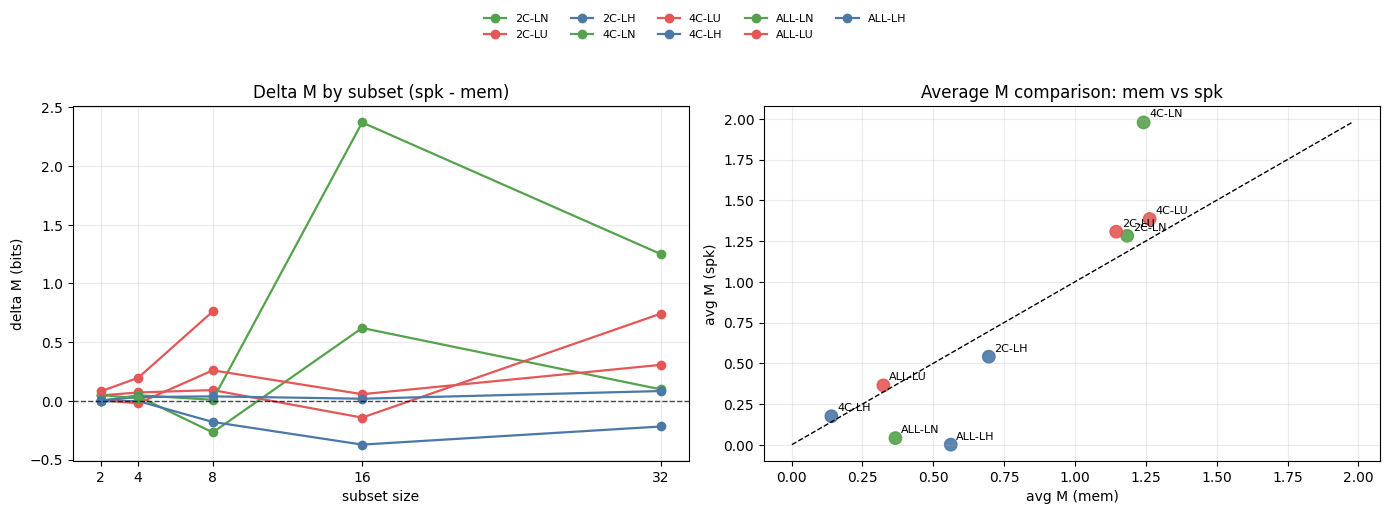


Average M used for final 9-network scatter
         network_id  short                          display      task                 arch  final_test_acc  avg_M_mem
2class_fittedhet_ln  2C-LN      2-class | FittedHet-LogNorm   2-class    FittedHet-LogNorm          0.8723     1.1843
2class_fittedhet_lu  2C-LU   2-class | FittedHet-LogUniform   2-class FittedHet-LogUniform          0.8304     1.1455
   2class_local_hom  2C-LH              2-class | Local-Hom   2-class            Local-Hom          0.8149     0.6958
4class_fittedhet_ln  4C-LN      4-class | FittedHet-LogNorm   4-class    FittedHet-LogNorm          0.6246     1.2421
4class_fittedhet_lu  4C-LU   4-class | FittedHet-LogUniform   4-class FittedHet-LogUniform          0.5936     1.2633
   4class_local_hom  4C-LH              4-class | Local-Hom   4-class            Local-Hom          0.5137     0.1404
   all_fittedhet_ln ALL-LN    All-class | FittedHet-LogNorm all-class    FittedHet-LogNorm          0.6904     0.3663
   all_fitte

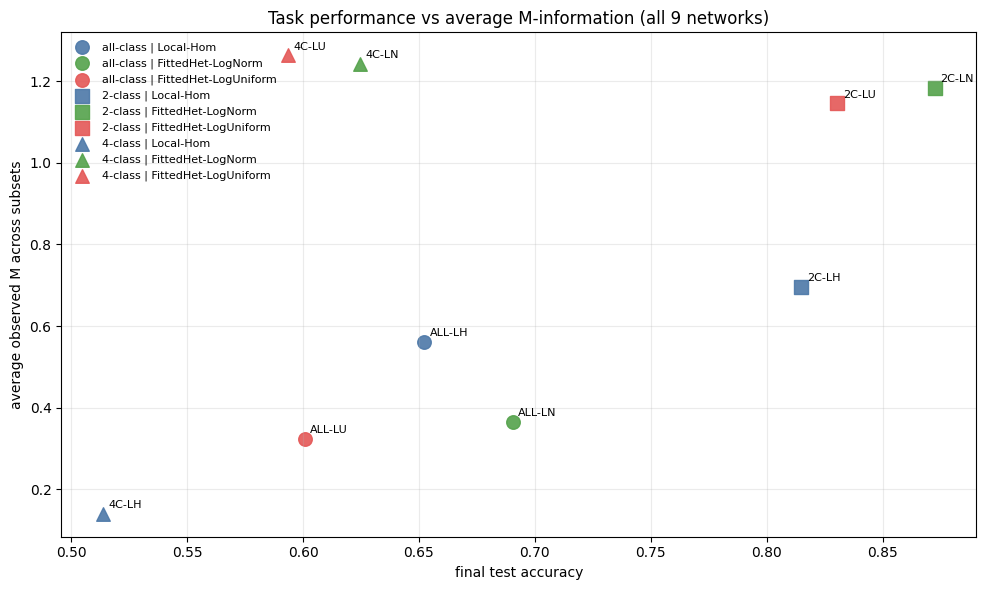

In [ ]:
if 'dedup_legend' not in globals():
    def dedup_legend(ax):
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        return list(unique.values()), list(unique.keys())

mem_switch_df = mem_df[["network_id", "short", "display", "task", "arch", "subset_size", "observed_M_bits", "observed_W_bits", "final_test_acc"]].copy()
spk_switch_df = spk_df[["network_id", "short", "display", "task", "arch", "subset_size", "observed_M_bits", "observed_W_bits"]].copy()

if spk_switch_df.empty:
    raise RuntimeError("No spike-based sweeps available. Verify spike artifact generation.")

switch_df = mem_switch_df.merge(
    spk_switch_df,
    on=["network_id", "short", "display", "task", "arch", "subset_size"],
    how="inner",
    suffixes=("_mem", "_spk"),
)

switch_df["delta_M_spk_minus_mem"] = switch_df["observed_M_bits_spk"] - switch_df["observed_M_bits_mem"]
switch_df["delta_W_spk_minus_mem"] = switch_df["observed_W_bits_spk"] - switch_df["observed_W_bits_mem"]

switch_summary = (
    switch_df.groupby(["network_id", "short", "display", "task", "arch", "final_test_acc"], as_index=False)[
        ["observed_M_bits_mem", "observed_M_bits_spk", "delta_M_spk_minus_mem", "observed_W_bits_mem", "observed_W_bits_spk", "delta_W_spk_minus_mem"]
    ]
    .mean()
    .rename(
        columns={
            "observed_M_bits_mem": "avg_M_mem",
            "observed_M_bits_spk": "avg_M_spk",
            "observed_W_bits_mem": "avg_W_mem",
            "observed_W_bits_spk": "avg_W_spk",
        }
    )
    .sort_values(["task", "arch", "short"])
)

print("Average mem->spk change table (all networks with both tensors)")
print("-" * 120)
print(switch_summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nSubset-wise delta M table (spk - mem)")
pivot_delta_m = switch_df.pivot(index="subset_size", columns="short", values="delta_M_spk_minus_mem").reindex(index=SUBSET_SIZES)
print(pivot_delta_m.to_string(float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for network_id, group in switch_df.groupby("network_id"):
    short = group["short"].iloc[0]
    arch = group["arch"].iloc[0]
    color = ARCH_COLORS.get(arch, "#666666")
    axes[0].plot(group["subset_size"], group["delta_M_spk_minus_mem"], marker="o", linewidth=1.6, color=color, label=short)

axes[0].axhline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
axes[0].set_title("Delta M by subset (spk - mem)")
axes[0].set_xlabel("subset size")
axes[0].set_ylabel("delta M (bits)")
axes[0].set_xticks(SUBSET_SIZES)
axes[0].grid(alpha=0.25)

axes[1].scatter(switch_summary["avg_M_mem"], switch_summary["avg_M_spk"], s=80, c=[ARCH_COLORS.get(a, "#666666") for a in switch_summary["arch"]], alpha=0.9)
for _, row in switch_summary.iterrows():
    axes[1].annotate(row["short"], (row["avg_M_mem"], row["avg_M_spk"]), textcoords="offset points", xytext=(4, 4), fontsize=8)

finite_mask = np.isfinite(switch_summary["avg_M_mem"]) & np.isfinite(switch_summary["avg_M_spk"])
if finite_mask.any():
    lo = float(min(switch_summary.loc[finite_mask, "avg_M_mem"].min(), switch_summary.loc[finite_mask, "avg_M_spk"].min()))
    hi = float(max(switch_summary.loc[finite_mask, "avg_M_mem"].max(), switch_summary.loc[finite_mask, "avg_M_spk"].max()))
    axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1.0)

axes[1].set_title("Average M comparison: mem vs spk")
axes[1].set_xlabel("avg M (mem)")
axes[1].set_ylabel("avg M (spk)")
axes[1].grid(alpha=0.25)

h, l = dedup_legend(axes[0])
fig.legend(h, l, loc="upper center", ncol=5, frameon=False, fontsize=8, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

final_scatter_df = (
    mem_df.groupby(["network_id", "short", "display", "task", "arch", "final_test_acc"], as_index=False)["observed_M_bits"]
    .mean()
    .rename(columns={"observed_M_bits": "avg_M_mem"})
    .sort_values(["task", "arch", "short"])
)

print("\nAverage M used for final 9-network scatter")
print(final_scatter_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(10, 6))
for task_name in TASK_ORDER:
    task_rows = final_scatter_df[final_scatter_df["task"] == task_name]
    for arch_name in ARCH_ORDER:
        rows = task_rows[task_rows["arch"] == arch_name]
        if rows.empty:
            continue
        ax.scatter(
            rows["avg_M_mem"],
            rows["final_test_acc"],
            s=95,
            marker=TASK_MARKERS.get(task_name, "o"),
            color=ARCH_COLORS.get(arch_name, "#666666"),
            alpha=0.9,
            label=f"{task_name} | {arch_name}",
        )

for _, row in final_scatter_df.iterrows():
    ax.annotate(row["short"], (row["avg_M_mem"], row["final_test_acc"]), textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_title("Average M-information vs task performance (all 9 networks)")
ax.set_xlabel("average observed M across subsets")
ax.set_ylabel("final test accuracy")
ax.grid(alpha=0.25)

handles, labels = dedup_legend(ax)
ax.legend(handles, labels, fontsize=8, frameon=False, loc="best")
plt.tight_layout()
plt.show()


## Z-Score Cross-Task Comparison

This section examines M-information z-scores across all three tasks and nine networks to assess:

1. **Per-task heatmaps** — architecture × subset-size z-score grids for each task individually.
2. **Architecture profiles across tasks** — how the same architecture family behaves on different tasks.
3. **Heterogeneous advantage** — z-score delta (best FittedHet minus Local-Hom) per task per subset, quantifying how much more synergistic the heterogeneous networks are.
4. **Full-subset (k=32) summary** — side-by-side z-score and −log₁₀(p) bar charts across all nine networks, grouped by task.


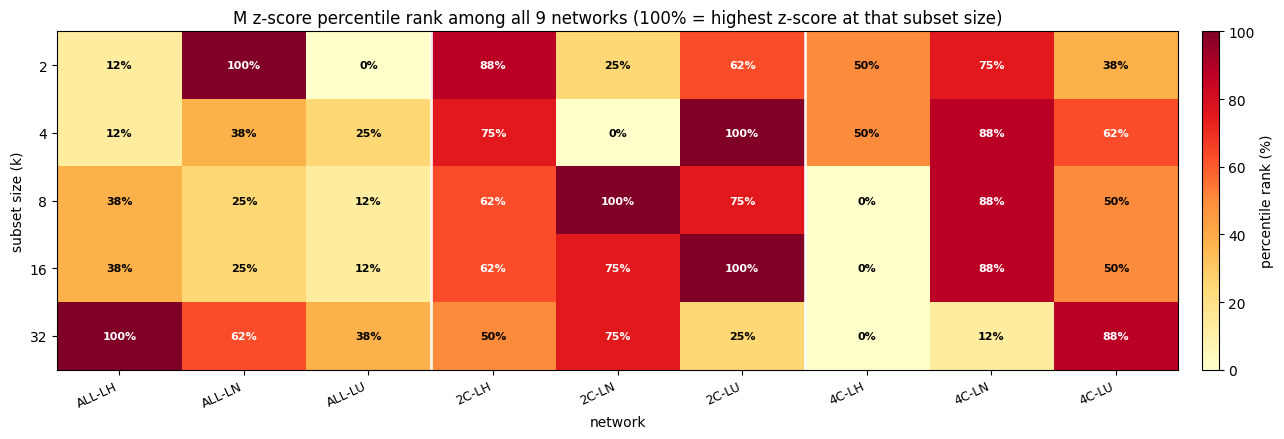

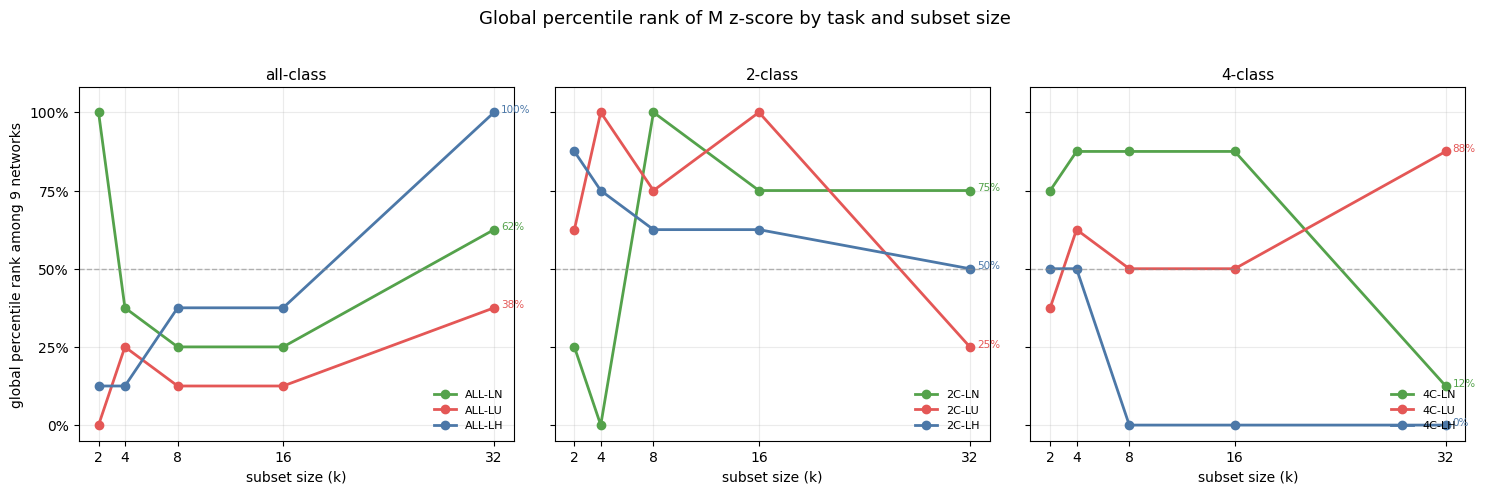

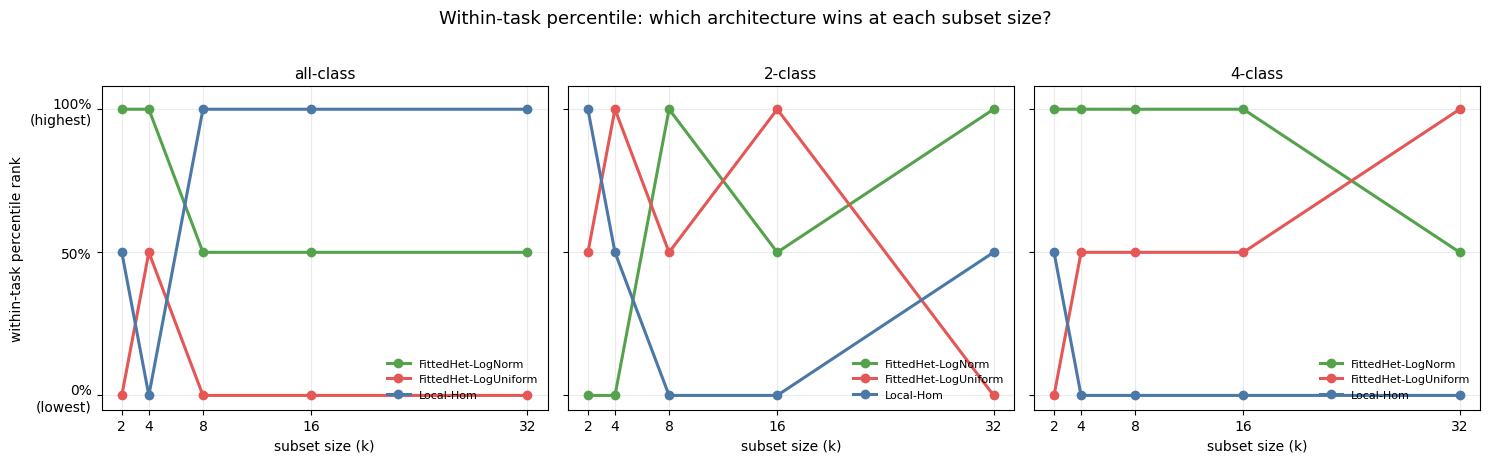

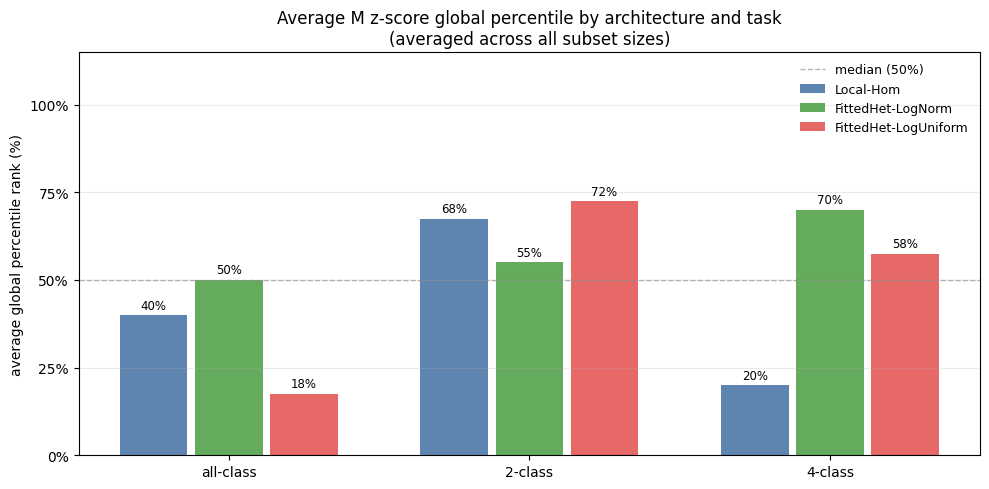


Global percentile rank table (M z-score, mem, all subset sizes)
------------------------------------------------------------------------------------------
short        ALL-LH  ALL-LN  ALL-LU  2C-LH  2C-LN  2C-LU  4C-LH  4C-LN  4C-LU
subset_size                                                                  
2             12.5%  100.0%    0.0%  87.5%  25.0%  62.5%  50.0%  75.0%  37.5%
4             12.5%   37.5%   25.0%  75.0%   0.0% 100.0%  50.0%  87.5%  62.5%
8             37.5%   25.0%   12.5%  62.5% 100.0%  75.0%   0.0%  87.5%  50.0%
16            37.5%   25.0%   12.5%  62.5%  75.0% 100.0%   0.0%  87.5%  50.0%
32           100.0%   62.5%   37.5%  50.0%  75.0%  25.0%   0.0%  12.5%  87.5%

Average global percentile rank by architecture and task
------------------------------------------------------------
task                  all-class  2-class  4-class
arch                                             
Local-Hom                 40.0%    67.5%    20.0%
FittedHet-LogNorm         50.0

In [11]:
from scipy.stats import norm as scipy_norm

# ── Build working frame ───────────────────────────────────────────────────────
z_base = mem_df[["network_id", "short", "task", "arch", "subset_size", "M_zscore", "M_p_upper"]].copy()
z_base = z_base[np.isfinite(z_base["M_zscore"])].copy()

# Percentile rank among ALL 9 networks at each subset size (0–100).
# Uses (rank - 1) / (n - 1) * 100 so the top scorer = 100%, bottom = 0%.
def percentile_rank(series):
    n = len(series)
    if n <= 1:
        return series * 0.0 + 50.0
    ranks = series.rank(method="average")
    return (ranks - 1) / (n - 1) * 100.0

z_base["pct_global"] = (
    z_base.groupby("subset_size")["M_zscore"]
    .transform(percentile_rank)
)

# Within-task percentile rank (rank among the 3 networks sharing the same task + subset).
z_base["pct_within_task"] = (
    z_base.groupby(["task", "subset_size"])["M_zscore"]
    .transform(percentile_rank)
)

short_order = [e["short"] for e in NETWORK_CATALOG]

# ── Plot 1: Global percentile rank heatmap ────────────────────────────────────
pivot_pct = (
    z_base.pivot(index="subset_size", columns="short", values="pct_global")
    .reindex(index=SUBSET_SIZES, columns=short_order)
)

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(pivot_pct.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
ax.set_title("M z-score percentile rank among all 9 networks (100% = highest z-score at that subset size)", fontsize=12)
ax.set_xlabel("network")
ax.set_ylabel("subset size (k)")
ax.set_xticks(np.arange(len(short_order)))
ax.set_xticklabels(short_order, rotation=25, ha="right", fontsize=9)
ax.set_yticks(np.arange(len(SUBSET_SIZES)))
ax.set_yticklabels(SUBSET_SIZES)

for i, k in enumerate(SUBSET_SIZES):
    for j, s in enumerate(short_order):
        val = pivot_pct.loc[k, s] if k in pivot_pct.index and s in pivot_pct.columns else np.nan
        if np.isfinite(val):
            text_color = "black" if val < 60 else "white"
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8, color=text_color, fontweight="bold")

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="percentile rank (%)")

# Annotate task boundaries
task_boundaries = [3, 6]  # after ALL-LU and 2C-LU
for xb in task_boundaries:
    ax.axvline(xb - 0.5, color="white", linewidth=2.0, alpha=0.9)

plt.tight_layout()
plt.show()

# ── Plot 2: Global percentile curves, one panel per task ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, task_name in zip(axes, TASK_ORDER):
    task_rows = z_base[z_base["task"] == task_name].sort_values("subset_size")
    for network_id, grp in task_rows.groupby("network_id"):
        arch = grp["arch"].iloc[0]
        short = grp["short"].iloc[0]
        ax.plot(
            grp["subset_size"],
            grp["pct_global"],
            marker="o",
            linewidth=2.0,
            color=ARCH_COLORS.get(arch, "#666666"),
            label=short,
        )
        # Annotate final point
        last = grp.sort_values("subset_size").iloc[-1]
        ax.annotate(
            f"{last['pct_global']:.0f}%",
            (last["subset_size"], last["pct_global"]),
            textcoords="offset points",
            xytext=(5, 0),
            fontsize=7.5,
            color=ARCH_COLORS.get(arch, "#666666"),
        )

    ax.axhline(50, color="#888888", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title(f"{task_name}", fontsize=11)
    ax.set_xlabel("subset size (k)")
    ax.set_ylim(-5, 108)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_xticks(SUBSET_SIZES)
    ax.grid(alpha=0.25)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, l, fontsize=8, frameon=False, loc="lower right")

axes[0].set_ylabel("global percentile rank among 9 networks")
plt.suptitle("Global percentile rank of M z-score by task and subset size", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Plot 3: Within-task percentile — architecture advantage per task ──────────
# For each task, show per-arch the within-task pct at each subset.
# (3 arches → ranks 0%, 50%, 100% — shows which arch wins within the task.)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, task_name in zip(axes, TASK_ORDER):
    task_rows = z_base[z_base["task"] == task_name].sort_values("subset_size")
    for network_id, grp in task_rows.groupby("network_id"):
        arch = grp["arch"].iloc[0]
        short = grp["short"].iloc[0]
        ax.plot(
            grp["subset_size"],
            grp["pct_within_task"],
            marker="o",
            linewidth=2.2,
            color=ARCH_COLORS.get(arch, "#666666"),
            label=arch,
        )

    ax.set_title(f"{task_name}", fontsize=11)
    ax.set_xlabel("subset size (k)")
    ax.set_ylim(-5, 108)
    ax.set_yticks([0, 50, 100])
    ax.set_yticklabels(["0%\n(lowest)", "50%", "100%\n(highest)"])
    ax.set_xticks(SUBSET_SIZES)
    ax.grid(alpha=0.25)
    h, l = ax.get_legend_handles_labels()
    unique = dict(zip(l, h))
    ax.legend(unique.values(), unique.keys(), fontsize=8, frameon=False, loc="lower right")

axes[0].set_ylabel("within-task percentile rank")
plt.suptitle("Within-task percentile: which architecture wins at each subset size?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Plot 4: Average global percentile by architecture and task ────────────────
avg_pct = (
    z_base.groupby(["task", "arch"], as_index=False)["pct_global"]
    .mean()
    .rename(columns={"pct_global": "avg_pct_global"})
)
avg_pct["_task_rank"] = avg_pct["task"].map({t: i for i, t in enumerate(TASK_ORDER)})
avg_pct["_arch_rank"] = avg_pct["arch"].map({a: i for i, a in enumerate(ARCH_ORDER)})
avg_pct = avg_pct.sort_values(["_task_rank", "_arch_rank"]).reset_index(drop=True)

n_tasks = len(TASK_ORDER)
n_archs = len(ARCH_ORDER)
x = np.arange(n_tasks)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for arch_idx, arch_name in enumerate(ARCH_ORDER):
    vals = []
    for task_name in TASK_ORDER:
        subset = avg_pct[(avg_pct["task"] == task_name) & (avg_pct["arch"] == arch_name)]
        vals.append(float(subset["avg_pct_global"].iloc[0]) if not subset.empty else np.nan)

    offset = (arch_idx - 1) * width
    bars = ax.bar(x + offset, vals, width=width * 0.9, color=ARCH_COLORS[arch_name], alpha=0.9, label=arch_name)
    for bar, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 1.0, f"{v:.0f}%", ha="center", va="bottom", fontsize=8.5)

ax.axhline(50, color="#888888", linestyle="--", linewidth=1.0, alpha=0.6, label="median (50%)")
ax.set_xticks(x)
ax.set_xticklabels(TASK_ORDER, fontsize=10)
ax.set_ylabel("average global percentile rank (%)")
ax.set_ylim(0, 115)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_title("Average M z-score global percentile by architecture and task\n(averaged across all subset sizes)", fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nGlobal percentile rank table (M z-score, mem, all subset sizes)")
print("-" * 90)
print(pivot_pct.to_string(float_format=lambda v: f"{v:.1f}%"))

print("\nAverage global percentile rank by architecture and task")
print("-" * 60)
pivot_avg = avg_pct.pivot(index="arch", columns="task", values="avg_pct_global").reindex(index=ARCH_ORDER, columns=TASK_ORDER)
print(pivot_avg.to_string(float_format=lambda v: f"{v:.1f}%"))


## Convergence Audit Across Networks

This section checks whether each trained network appears converged or simply stopped at the fixed epoch limit.

Convergence diagnostics are computed from saved training history using:
- best-epoch vs final-epoch test accuracy gap
- last-5-epoch test-accuracy trend and variability
- final train-test gap (overfit indicator)

Convergence table
------------------------------------------------------------------------------------------------------------------------------------------------------
      short      task                 arch  epochs  best_epoch  best_test_acc  final_test_acc  best_minus_final  tail_delta_last5  tail_std_last5  final_train_test_gap converged                status
     ALL-LH all-class            Local-Hom      25          25         0.6524          0.6524            0.0000            0.0914          0.0477               -0.0003        no       still improving
     ALL-LN all-class    FittedHet-LogNorm      25          23         0.7129          0.6904            0.0225            0.0186          0.0257                0.1483        no          near plateau
     ALL-LU all-class FittedHet-LogUniform      25          25         0.6007          0.6007            0.0000            0.0327          0.0134                0.1105        no       still improving
ALL-RepoHet all-class     Repo-

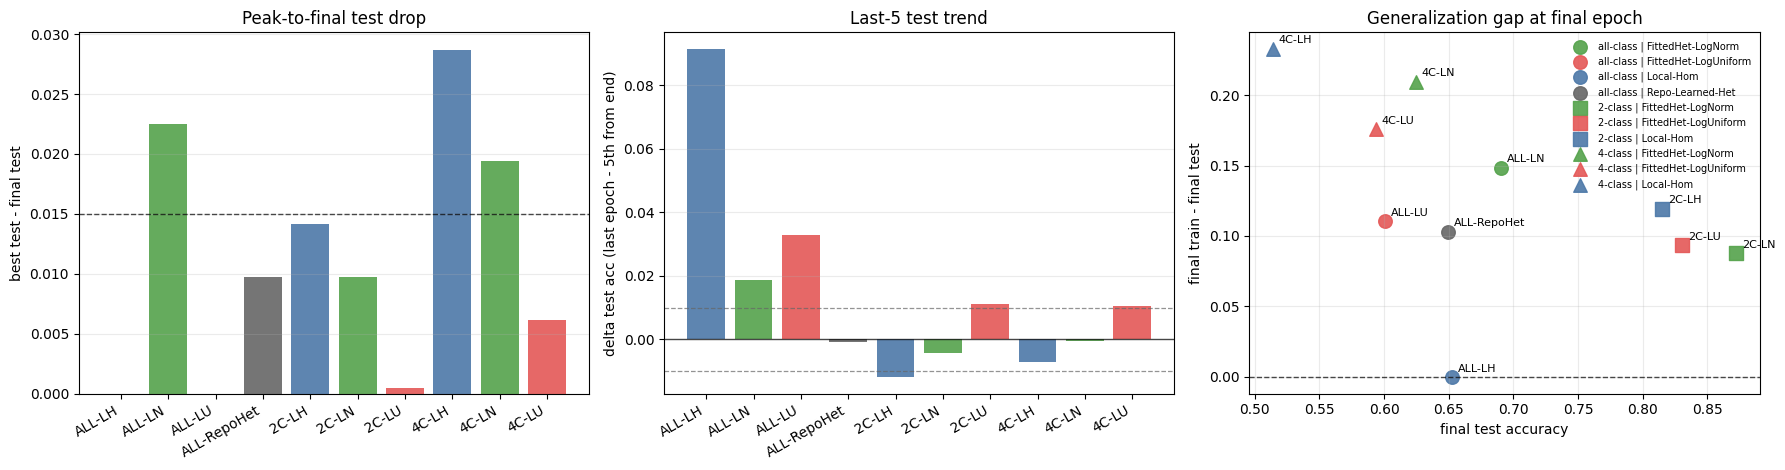

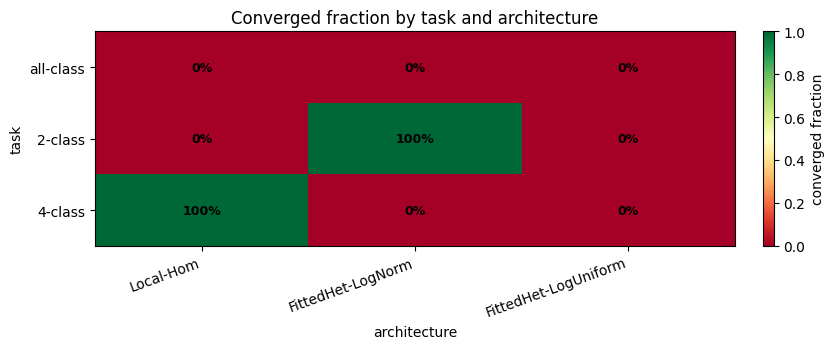


Status counts
----------------------------------------
               status  count
         near plateau      3
plateaued / converged      3
      still improving      2
                mixed      2


In [10]:
convergence_rows = []
convergence_entries = list(NETWORK_CATALOG) + [REPO_REFERENCE]

for entry in convergence_entries:
    ckpt_path = Path(entry["checkpoint"])
    base_row = {
        "network_id": entry["network_id"],
        "short": entry["short"],
        "task": entry["task"],
        "arch": entry["arch"],
        "checkpoint": str(ckpt_path),
    }

    if not ckpt_path.exists():
        convergence_rows.append(
            {
                **base_row,
                "epochs": np.nan,
                "best_epoch": np.nan,
                "best_test_acc": np.nan,
                "final_test_acc": np.nan,
                "best_minus_final": np.nan,
                "tail_delta_last5": np.nan,
                "tail_std_last5": np.nan,
                "final_train_test_gap": np.nan,
                "converged": False,
                "status": "missing checkpoint",
            }
        )
        continue

    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    history = ckpt.get("history", {})
    train_acc = np.asarray(history.get("train_acc", []), dtype=float)
    test_acc = np.asarray(history.get("test_acc", []), dtype=float)

    finite_idx = np.where(np.isfinite(test_acc))[0]
    if finite_idx.size == 0:
        convergence_rows.append(
            {
                **base_row,
                "epochs": np.nan,
                "best_epoch": np.nan,
                "best_test_acc": np.nan,
                "final_test_acc": np.nan,
                "best_minus_final": np.nan,
                "tail_delta_last5": np.nan,
                "tail_std_last5": np.nan,
                "final_train_test_gap": np.nan,
                "converged": False,
                "status": "missing history",
            }
        )
        continue

    n_epochs = int(test_acc.size)
    best_idx = int(finite_idx[np.argmax(test_acc[finite_idx])])
    best_epoch = best_idx + 1
    best_test = float(test_acc[best_idx])
    final_test = float(test_acc[-1])
    best_minus_final = float(best_test - final_test)

    tail_len = int(min(5, n_epochs))
    tail = test_acc[-tail_len:]
    if tail_len > 1:
        tail_delta = float(tail[-1] - tail[0])
    else:
        tail_delta = 0.0
    tail_std = float(np.nanstd(tail))

    final_train = float(train_acc[-1]) if train_acc.size else np.nan
    train_test_gap = float(final_train - final_test) if np.isfinite(final_train) else np.nan

    reached_late_peak = best_epoch >= max(n_epochs - 2, 1)
    flat_tail = (abs(tail_delta) <= 0.010) and (tail_std <= 0.015)
    small_peak_drop = best_minus_final <= 0.015
    converged = bool(flat_tail and (small_peak_drop or reached_late_peak))

    if best_epoch == n_epochs and tail_delta > 0.010:
        status = "still improving"
    elif best_minus_final > 0.025 and best_epoch <= n_epochs - 4:
        status = "peaked then regressed"
    elif converged:
        status = "plateaued / converged"
    elif reached_late_peak and abs(tail_delta) <= 0.020:
        status = "near plateau"
    else:
        status = "mixed"

    convergence_rows.append(
        {
            **base_row,
            "epochs": n_epochs,
            "best_epoch": best_epoch,
            "best_test_acc": best_test,
            "final_test_acc": final_test,
            "best_minus_final": best_minus_final,
            "tail_delta_last5": tail_delta,
            "tail_std_last5": tail_std,
            "final_train_test_gap": train_test_gap,
            "converged": converged,
            "status": status,
        }
    )

convergence_df = pd.DataFrame(convergence_rows)

task_rank = {task: idx for idx, task in enumerate(TASK_ORDER)}
arch_rank = {arch: idx for idx, arch in enumerate(ARCH_ORDER)}
convergence_df["_task_rank"] = convergence_df["task"].map(lambda x: task_rank.get(x, len(task_rank)))
convergence_df["_arch_rank"] = convergence_df["arch"].map(lambda x: arch_rank.get(x, len(arch_rank)))
convergence_df = convergence_df.sort_values(["_task_rank", "_arch_rank", "short"]).reset_index(drop=True)

display_cols = [
    "short",
    "task",
    "arch",
    "epochs",
    "best_epoch",
    "best_test_acc",
    "final_test_acc",
    "best_minus_final",
    "tail_delta_last5",
    "tail_std_last5",
    "final_train_test_gap",
    "converged",
    "status",
]
display_df = convergence_df[display_cols].copy()
display_df["converged"] = np.where(display_df["converged"], "yes", "no")

print("Convergence table")
print("-" * 150)
print(display_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

plot_df = convergence_df[convergence_df["epochs"].notna()].copy()
if plot_df.empty:
    raise RuntimeError("No valid checkpoint histories were found for convergence plots.")

plot_df = plot_df.reset_index(drop=True)
x = np.arange(len(plot_df))
short_labels = plot_df["short"].tolist()
bar_colors = [ARCH_COLORS.get(arch, "#666666") for arch in plot_df["arch"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].bar(x, plot_df["best_minus_final"], color=bar_colors, alpha=0.9)
axes[0].axhline(0.015, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
axes[0].set_title("Peak-to-final test drop")
axes[0].set_ylabel("best test - final test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_labels, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x, plot_df["tail_delta_last5"], color=bar_colors, alpha=0.9)
axes[1].axhline(0.0, color="k", linestyle="-", linewidth=1.0, alpha=0.7)
axes[1].axhline(0.010, color="#666666", linestyle="--", linewidth=0.9, alpha=0.7)
axes[1].axhline(-0.010, color="#666666", linestyle="--", linewidth=0.9, alpha=0.7)
axes[1].set_title("Last-5 test trend")
axes[1].set_ylabel("delta test acc (last epoch - 5th from end)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels, rotation=30, ha="right")
axes[1].grid(axis="y", alpha=0.25)

for task_name in TASK_ORDER:
    task_rows = plot_df[plot_df["task"] == task_name]
    for arch_name, group in task_rows.groupby("arch"):
        axes[2].scatter(
            group["final_test_acc"],
            group["final_train_test_gap"],
            s=95,
            marker=TASK_MARKERS.get(task_name, "o"),
            color=ARCH_COLORS.get(arch_name, "#666666"),
            alpha=0.9,
            label=f"{task_name} | {arch_name}",
        )

for _, row in plot_df.iterrows():
    if np.isfinite(row["final_test_acc"]) and np.isfinite(row["final_train_test_gap"]):
        axes[2].annotate(
            row["short"],
            (row["final_test_acc"], row["final_train_test_gap"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

axes[2].axhline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
axes[2].set_title("Generalization gap at final epoch")
axes[2].set_xlabel("final test accuracy")
axes[2].set_ylabel("final train - final test")
axes[2].grid(alpha=0.25)
if "dedup_legend" in globals():
    h, l = dedup_legend(axes[2])
    axes[2].legend(h, l, fontsize=7, frameon=False, loc="best")
else:
    axes[2].legend(fontsize=7, frameon=False, loc="best")

plt.tight_layout()
plt.show()

heat_df = plot_df[plot_df["task"].isin(TASK_ORDER) & plot_df["arch"].isin(ARCH_ORDER)].copy()
if not heat_df.empty:
    pivot_conv = (
        heat_df.pivot_table(index="task", columns="arch", values="converged", aggfunc="mean")
        .reindex(index=TASK_ORDER, columns=ARCH_ORDER)
    )

    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    im = ax.imshow(pivot_conv.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap="RdYlGn", aspect="auto")
    ax.set_title("Converged fraction by task and architecture")
    ax.set_xlabel("architecture")
    ax.set_ylabel("task")
    ax.set_xticks(np.arange(len(ARCH_ORDER)))
    ax.set_xticklabels(ARCH_ORDER, rotation=20, ha="right")
    ax.set_yticks(np.arange(len(TASK_ORDER)))
    ax.set_yticklabels(TASK_ORDER)

    for i, task_name in enumerate(TASK_ORDER):
        for j, arch_name in enumerate(ARCH_ORDER):
            val = pivot_conv.loc[task_name, arch_name]
            text = "n/a" if not np.isfinite(val) else f"{val:.0%}"
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=9, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="converged fraction")
    plt.tight_layout()
    plt.show()

status_counts = plot_df["status"].value_counts().rename_axis("status").reset_index(name="count")
print("\nStatus counts")
print("-" * 40)
print(status_counts.to_string(index=False))

## Manifold Representation Across Networks and Time Steps

This section builds a manifold view of hidden-state snapshots for all networks across a spread of time steps.

It plots separation in 2D using PCA (and optionally t-SNE), and reports how centroid separation changes over time.

C:\Users\Priya\AppData\Local\Temp\ipykernel_37680\1313668158.py:177: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(short_order))


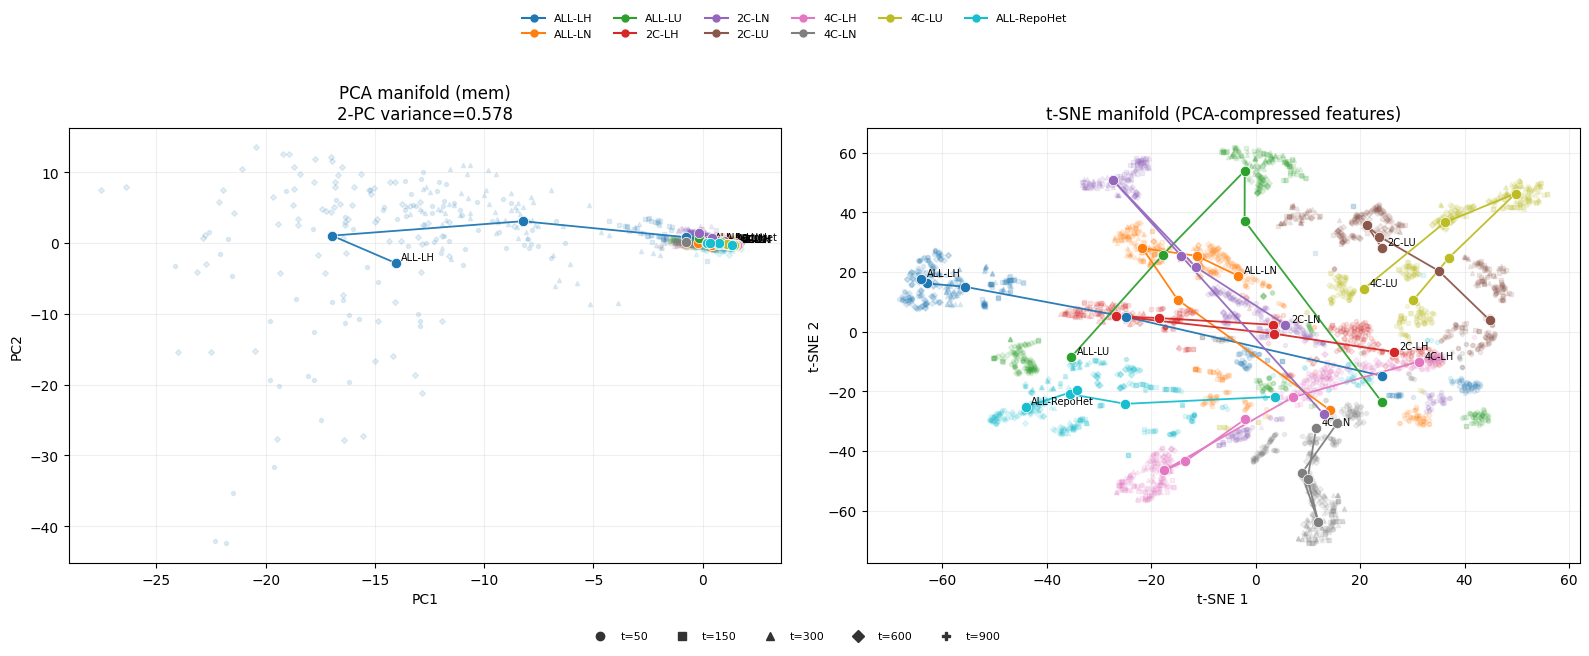

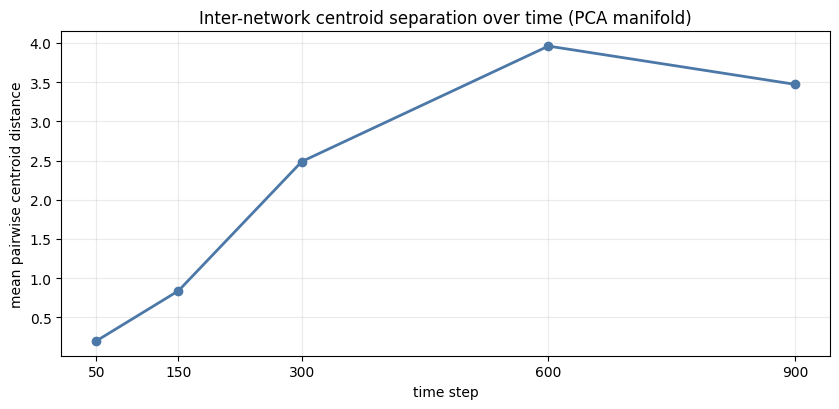

Manifold dataset summary
----------------------------------------------------------------------------------------------------
Networks included: 10
Tensor key: mem
Time steps: [50, 150, 300, 600, 900]
Total manifold points: 4000
2-PC explained variance: 0.5782
Silhouette (PCA, by network): -0.2309
Silhouette (t-SNE, by network): 0.0724

Centroid separation by time step (PCA)
----------------------------------------------------------------------------------------------------
 time_step  mean_pairwise_centroid_dist_pca
        50                           0.1985
       150                           0.8383
       300                           2.4866
       600                           3.9596
       900                           3.4715


In [13]:
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# ---------------------------- Config -----------------------------------------
MANIFOLD_INCLUDE_REPO = True
MANIFOLD_TENSOR_KEY = "mem"        # "mem" or "spk"
MANIFOLD_TIME_STEPS = [50, 150, 300, 600, 900]
MANIFOLD_MAX_BATCHES = 2
MANIFOLD_SAMPLE_STRIDE = 2          # keep every nth sample in each batch
MANIFOLD_MAX_POINTS_PER_GROUP = 80  # per (network, time_step) group
MANIFOLD_RANDOM_SEED = 7
MANIFOLD_RUN_TSNE = True

if MANIFOLD_TENSOR_KEY not in {"mem", "spk"}:
    raise ValueError("MANIFOLD_TENSOR_KEY must be 'mem' or 'spk'")

if "SHD_TEST_CACHE" not in globals():
    SHD_TEST_CACHE = SHDCache(SHD_TEST)

manifold_entries = list(NETWORK_CATALOG)
if MANIFOLD_INCLUDE_REPO:
    manifold_entries = manifold_entries + [REPO_REFERENCE]

manifold_time_steps = sorted({int(t) for t in MANIFOLD_TIME_STEPS if int(t) >= 0})
if not manifold_time_steps:
    raise RuntimeError("No valid time steps supplied for manifold extraction.")


@torch.no_grad()
def collect_hidden_time_snapshots(
    model,
    prms,
    data_source,
    time_steps,
    tensor_key="mem",
    max_batches=2,
    sample_stride=1,
):
    if not _is_cache(data_source):
        raise RuntimeError("Expected SHDCache for data_source")

    sample_stride = max(int(sample_stride), 1)
    blocks = []
    meta_rows = []

    with shd_open_cached(data_source) as (units, times, labels):
        for bidx, (x, _y) in enumerate(
            shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)
        ):
            if bidx >= int(max_batches):
                break

            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            hidden = layer_recs[0][1] if tensor_key == "mem" else layer_recs[0][0]
            hidden_np = hidden.detach().cpu().numpy()[::sample_stride, :, :]

            if hidden_np.size == 0:
                continue

            n_batch, n_steps, _n_hidden = hidden_np.shape
            valid_ts = [t for t in time_steps if 0 <= int(t) < n_steps]
            for t in valid_ts:
                t = int(t)
                snap = hidden_np[:, t, :].astype(np.float64)
                blocks.append(snap)
                meta_rows.extend([{"time_step": t}] * snap.shape[0])

    if not blocks:
        raise RuntimeError("No hidden snapshots collected. Increase max_batches or verify data.")

    return np.vstack(blocks), pd.DataFrame(meta_rows)


feature_blocks = []
meta_parts = []
for entry in manifold_entries:
    model, prms, _payload = load_model_from_checkpoint(entry["checkpoint"])

    x_net, meta_net = collect_hidden_time_snapshots(
        model,
        prms,
        SHD_TEST_CACHE,
        manifold_time_steps,
        tensor_key=MANIFOLD_TENSOR_KEY,
        max_batches=MANIFOLD_MAX_BATCHES,
        sample_stride=MANIFOLD_SAMPLE_STRIDE,
    )

    meta_net["network_id"] = entry["network_id"]
    meta_net["short"] = entry["short"]
    meta_net["task"] = entry["task"]
    meta_net["arch"] = entry["arch"]

    feature_blocks.append(x_net)
    meta_parts.append(meta_net)

X = np.vstack(feature_blocks)
manifold_df = pd.concat(meta_parts, ignore_index=True)

# Downsample per (network, timestep) group for balanced visualization
if MANIFOLD_MAX_POINTS_PER_GROUP is not None:
    rng = np.random.default_rng(MANIFOLD_RANDOM_SEED)
    keep_idx = []
    for _, idx in manifold_df.groupby(["short", "time_step"]).indices.items():
        idx_arr = np.asarray(list(idx), dtype=int)
        if idx_arr.size > int(MANIFOLD_MAX_POINTS_PER_GROUP):
            idx_arr = rng.choice(idx_arr, size=int(MANIFOLD_MAX_POINTS_PER_GROUP), replace=False)
        keep_idx.extend(idx_arr.tolist())

    keep_idx = np.asarray(sorted(keep_idx), dtype=int)
    X = X[keep_idx, :]
    manifold_df = manifold_df.iloc[keep_idx].reset_index(drop=True)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X = X - X.mean(axis=0, keepdims=True)
scale = X.std(axis=0, keepdims=True)
scale[scale < 1e-8] = 1.0
X = X / scale

n_components = int(min(20, X.shape[1], max(2, X.shape[0] - 1)))
pca_model = PCA(n_components=n_components, random_state=MANIFOLD_RANDOM_SEED)
X_pca = pca_model.fit_transform(X)

manifold_df["pca_x"] = X_pca[:, 0]
manifold_df["pca_y"] = X_pca[:, 1]
pca_var2 = float(pca_model.explained_variance_ratio_[:2].sum())

# Optional nonlinear manifold (t-SNE) on PCA-compressed coordinates
tsne_ok = bool(MANIFOLD_RUN_TSNE and X_pca.shape[0] >= 100)
if tsne_ok:
    perplexity = max(10, min(40, int((X_pca.shape[0] - 1) // 3)))
    tsne_model = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        random_state=MANIFOLD_RANDOM_SEED,
        max_iter=1200,
    )
    X_tsne = tsne_model.fit_transform(X_pca[:, : min(20, X_pca.shape[1])])
    manifold_df["tsne_x"] = X_tsne[:, 0]
    manifold_df["tsne_y"] = X_tsne[:, 1]
else:
    manifold_df["tsne_x"] = np.nan
    manifold_df["tsne_y"] = np.nan

# Separation metrics
silhouette_pca = float("nan")
silhouette_tsne = float("nan")
if manifold_df["short"].nunique() > 1 and len(manifold_df) > manifold_df["short"].nunique():
    silhouette_pca = float(silhouette_score(manifold_df[["pca_x", "pca_y"]], manifold_df["short"]))
    if tsne_ok:
        silhouette_tsne = float(silhouette_score(manifold_df[["tsne_x", "tsne_y"]], manifold_df["short"]))

centroid_df = (
    manifold_df.groupby(["short", "task", "arch", "time_step"], as_index=False)[["pca_x", "pca_y", "tsne_x", "tsne_y"]]
    .mean()
)

sep_rows = []
for t in manifold_time_steps:
    subset = centroid_df[centroid_df["time_step"] == t]
    if len(subset) < 2:
        mean_pairwise = float("nan")
    else:
        mean_pairwise = float(pdist(subset[["pca_x", "pca_y"]].to_numpy(), metric="euclidean").mean())
    sep_rows.append({"time_step": int(t), "mean_pairwise_centroid_dist_pca": mean_pairwise})

separation_df = pd.DataFrame(sep_rows)

# ------------------------------ Plots -----------------------------------------
short_order = [entry["short"] for entry in manifold_entries]
palette = plt.cm.get_cmap("tab10", len(short_order))
short_colors = {short: palette(i) for i, short in enumerate(short_order)}

marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
time_markers = {t: marker_cycle[i % len(marker_cycle)] for i, t in enumerate(manifold_time_steps)}

network_handles = [
    Line2D([0], [0], marker="o", linestyle="-", linewidth=1.5, color=short_colors[s], label=s, markersize=5)
    for s in short_order
]
time_handles = [
    Line2D([0], [0], marker=time_markers[t], linestyle="None", color="#333333", label=f"t={t}", markersize=6)
    for t in manifold_time_steps
]

fig, axes = plt.subplots(1, 2 if tsne_ok else 1, figsize=(16 if tsne_ok else 8.5, 6))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# PCA panel
ax0 = axes[0]
for t in manifold_time_steps:
    t_rows = manifold_df[manifold_df["time_step"] == t]
    for short in short_order:
        rows = t_rows[t_rows["short"] == short]
        if rows.empty:
            continue
        ax0.scatter(
            rows["pca_x"],
            rows["pca_y"],
            s=9,
            alpha=0.12,
            color=short_colors[short],
            marker=time_markers[t],
            rasterized=True,
        )

for short in short_order:
    c = centroid_df[centroid_df["short"] == short].sort_values("time_step")
    if c.empty:
        continue
    ax0.plot(c["pca_x"], c["pca_y"], color=short_colors[short], linewidth=1.3, alpha=0.95)
    ax0.scatter(c["pca_x"], c["pca_y"], color=short_colors[short], s=55, edgecolor="white", linewidth=0.5, zorder=4)
    ax0.annotate(short, (c["pca_x"].iloc[-1], c["pca_y"].iloc[-1]), textcoords="offset points", xytext=(4, 2), fontsize=7)

ax0.set_title(f"PCA manifold ({MANIFOLD_TENSOR_KEY})\n2-PC variance={pca_var2:.3f}")
ax0.set_xlabel("PC1")
ax0.set_ylabel("PC2")
ax0.grid(alpha=0.2)

# t-SNE panel
if tsne_ok:
    ax1 = axes[1]
    for t in manifold_time_steps:
        t_rows = manifold_df[manifold_df["time_step"] == t]
        for short in short_order:
            rows = t_rows[t_rows["short"] == short]
            if rows.empty:
                continue
            ax1.scatter(
                rows["tsne_x"],
                rows["tsne_y"],
                s=9,
                alpha=0.12,
                color=short_colors[short],
                marker=time_markers[t],
                rasterized=True,
            )

    for short in short_order:
        c = centroid_df[centroid_df["short"] == short].sort_values("time_step")
        if c.empty:
            continue
        ax1.plot(c["tsne_x"], c["tsne_y"], color=short_colors[short], linewidth=1.3, alpha=0.95)
        ax1.scatter(c["tsne_x"], c["tsne_y"], color=short_colors[short], s=55, edgecolor="white", linewidth=0.5, zorder=4)
        ax1.annotate(short, (c["tsne_x"].iloc[-1], c["tsne_y"].iloc[-1]), textcoords="offset points", xytext=(4, 2), fontsize=7)

    ax1.set_title("t-SNE manifold (PCA-compressed features)")
    ax1.set_xlabel("t-SNE 1")
    ax1.set_ylabel("t-SNE 2")
    ax1.grid(alpha=0.2)

fig.legend(network_handles, [h.get_label() for h in network_handles], loc="upper center", ncol=6, frameon=False, fontsize=8, bbox_to_anchor=(0.5, 1.06))
fig.legend(time_handles, [h.get_label() for h in time_handles], loc="lower center", ncol=len(time_handles), frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(separation_df["time_step"], separation_df["mean_pairwise_centroid_dist_pca"], marker="o", linewidth=2.0, color="#4c78a8")
ax.set_title("Inter-network centroid separation over time (PCA manifold)")
ax.set_xlabel("time step")
ax.set_ylabel("mean pairwise centroid distance")
ax.grid(alpha=0.25)
ax.set_xticks(manifold_time_steps)
plt.tight_layout()
plt.show()

print("Manifold dataset summary")
print("-" * 100)
print(f"Networks included: {len(short_order)}")
print(f"Tensor key: {MANIFOLD_TENSOR_KEY}")
print(f"Time steps: {manifold_time_steps}")
print(f"Total manifold points: {len(manifold_df)}")
print(f"2-PC explained variance: {pca_var2:.4f}")
print(f"Silhouette (PCA, by network): {silhouette_pca:.4f}" if np.isfinite(silhouette_pca) else "Silhouette (PCA): n/a")
if tsne_ok:
    print(f"Silhouette (t-SNE, by network): {silhouette_tsne:.4f}" if np.isfinite(silhouette_tsne) else "Silhouette (t-SNE): n/a")

print("\nCentroid separation by time step (PCA)")
print("-" * 100)
print(separation_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))